# OD-Level Forecasting

This notebook develops one-hour-ahead origin-destination taxi flow forecasting models for Manhattan. It includes Manhattan-to-Manhattan filtering, training-only OD-pair selection, feature engineering, temporal data splitting, model training and evaluation.

In [1]:
# Importing the required libraries

import pandas as pd
import numpy as np

from pathlib import Path
from math import ceil

## Setting Input and Output Paths

In [2]:
# Defining the main project directories

project_dir = Path("..")

processed_dir = (project_dir/ "Data"/ "Processed")

output_dir = (project_dir/ "Output")


# Defining the hourly OD-flow input dataset

hourly_od_path = (processed_dir/ "hourly_od_flows_2024_01.parquet")

# Checking the required input dataset

print("Hourly OD-flow dataset exists:",hourly_od_path.exists())

Hourly OD-flow dataset exists: True


## Setting the Output Folders

In [3]:
# Setting the output folders

reports_dir = project_dir / "Output" / "Reports"
models_dir = project_dir / "Output" / "Models"
figures_dir = project_dir / "Output" / "Figures"

# Creating the folders if they do not already exist

reports_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("Reports folder:", reports_dir)
print("Models folder:", models_dir)
print("Figures folder:", figures_dir)

Reports folder: ..\Output\Reports
Models folder: ..\Output\Models
Figures folder: ..\Output\Figures


## Loading the Hourly OD-Flow Dataset

Loading the hourly OD-flow dataset created in Notebook 1 for Manhattan OD forecasting.

In [4]:
# Loading the processed hourly OD-flow dataset created in Notebook 1

hourly_od = pd.read_parquet(
    hourly_od_path
)


# Checking the dataset structure

print("Shape:", hourly_od.shape)

print(
    "\nStart time:",
    hourly_od["pickup_hour"].min()
)

print(
    "End time:",
    hourly_od["pickup_hour"].max()
)

print(
    "Unique hourly timestamps:",
    hourly_od["pickup_hour"].nunique()
)

print(
    "Total recorded trips:",
    hourly_od["trip_count"].sum()
)


# Displaying the first five records

display(hourly_od.head())

Shape: (1079578, 15)

Start time: 2024-01-01 00:00:00
End time: 2024-01-31 23:00:00
Unique hourly timestamps: 744
Total recorded trips: 2891287


,pickup_hour,PULocationID,DOLocationID,trip_count,hour,day,day_of_week,month,is_weekend,PU_Borough,PU_Zone,PU_service_zone,DO_Borough,DO_Zone,DO_service_zone
0,2024-01-01,4,13,1,0,1,0,1,0,Manhattan,Alphabet City,Yellow Zone,Manhattan,Battery Park City,Yellow Zone
1,2024-01-01,4,36,1,0,1,0,1,0,Manhattan,Alphabet City,Yellow Zone,Brooklyn,Bushwick North,Boro Zone
2,2024-01-01,4,68,1,0,1,0,1,0,Manhattan,Alphabet City,Yellow Zone,Manhattan,East Chelsea,Yellow Zone
3,2024-01-01,4,79,2,0,1,0,1,0,Manhattan,Alphabet City,Yellow Zone,Manhattan,East Village,Yellow Zone
4,2024-01-01,4,137,1,0,1,0,1,0,Manhattan,Alphabet City,Yellow Zone,Manhattan,Kips Bay,Yellow Zone


## Checking the OD Dataset Quality

Checking required columns, missing values, duplicate OD-hour records, and invalid trip counts before modelling.

In [5]:
# Defining the columns required for the OD forecasting workflow

required_columns = [
    "pickup_hour",
    "PULocationID",
    "DOLocationID",
    "trip_count",
    "PU_Borough",
    "PU_Zone",
    "DO_Borough",
    "DO_Zone"
]


# Checking whether any required columns are missing

missing_required_columns = [
    column
    for column in required_columns
    if column not in hourly_od.columns
]


# Checking duplicate timestamp and OD-pair combinations

duplicate_od_hours = hourly_od.duplicated(
    subset=[
        "pickup_hour",
        "PULocationID",
        "DOLocationID"
    ]
).sum()


# Checking non-positive observed trip counts

non_positive_trip_counts = (
    hourly_od["trip_count"] <= 0
).sum()


# Displaying the checks

print("Missing required columns:", missing_required_columns)
print("Total missing values:", hourly_od.isna().sum().sum())
print("Duplicate hourly OD records:", duplicate_od_hours)
print("Non-positive trip counts:", non_positive_trip_counts)

Missing required columns: []
Total missing values: 0
Duplicate hourly OD records: 0
Non-positive trip counts: 0


## Filtering to Manhattan-to-Manhattan OD Flows

Restricting the analysis to trips where both pickup and drop-off locations are within Manhattan.

In [6]:
# Restricting the OD dataset to trips where both the pickup
# and drop-off locations are within Manhattan

manhattan_od = hourly_od[
    (hourly_od["PU_Borough"] == "Manhattan")
    &
    (hourly_od["DO_Borough"] == "Manhattan")
].copy()


# Resetting the index after geographical filtering

manhattan_od = manhattan_od.reset_index(
    drop=True
)


# Calculating the percentage of total trip demand retained

manhattan_trip_percentage = (
    manhattan_od["trip_count"].sum()
    / hourly_od["trip_count"].sum()
) * 100


# Checking the filtered Manhattan OD dataset

print("Original hourly OD-flow shape:", hourly_od.shape)
print("Manhattan-to-Manhattan shape:", manhattan_od.shape)

print(
    "\nOriginal total trips:",
    hourly_od["trip_count"].sum()
)

print(
    "Manhattan-to-Manhattan trips:",
    manhattan_od["trip_count"].sum()
)

print(
    "Percentage of total trips retained:",
    round(manhattan_trip_percentage, 2),
    "%"
)

print(
    "\nPickup boroughs:",
    manhattan_od["PU_Borough"].unique().tolist()
)

print(
    "Drop-off boroughs:",
    manhattan_od["DO_Borough"].unique().tolist()
)


# Displaying the first five Manhattan OD records

display(manhattan_od.head())

Original hourly OD-flow shape: (1079578, 15)
Manhattan-to-Manhattan shape: (804551, 15)

Original total trips: 2891287
Manhattan-to-Manhattan trips: 2441818
Percentage of total trips retained: 84.45 %

Pickup boroughs: ['Manhattan']
Drop-off boroughs: ['Manhattan']


,pickup_hour,PULocationID,DOLocationID,trip_count,hour,day,day_of_week,month,is_weekend,PU_Borough,PU_Zone,PU_service_zone,DO_Borough,DO_Zone,DO_service_zone
0,2024-01-01,4,13,1,0,1,0,1,0,Manhattan,Alphabet City,Yellow Zone,Manhattan,Battery Park City,Yellow Zone
1,2024-01-01,4,68,1,0,1,0,1,0,Manhattan,Alphabet City,Yellow Zone,Manhattan,East Chelsea,Yellow Zone
2,2024-01-01,4,79,2,0,1,0,1,0,Manhattan,Alphabet City,Yellow Zone,Manhattan,East Village,Yellow Zone
3,2024-01-01,4,137,1,0,1,0,1,0,Manhattan,Alphabet City,Yellow Zone,Manhattan,Kips Bay,Yellow Zone
4,2024-01-01,4,141,1,0,1,0,1,0,Manhattan,Alphabet City,Yellow Zone,Manhattan,Lenox Hill West,Yellow Zone


The Manhattan-to-Manhattan subset retains 84.45% of the original trip demand, supporting Manhattan as the main study area for OD-level forecasting.

## Creating a Unique OD-Pair ID

Combining pickup and drop-off LocationIDs to create a unique identifier for each OD pair.

In [7]:
# Creating a unique identifier for each origin-destination pair
# The pickup and drop-off LocationIDs are combined into one OD-pair label

manhattan_od["od_pair"] = (
    manhattan_od["PULocationID"].astype(str)
    + "_"
    + manhattan_od["DOLocationID"].astype(str)
)


# Checking the created OD-pair identifiers

print(
    "Number of unique Manhattan OD pairs:",
    manhattan_od["od_pair"].nunique()
)

print(
    "Missing OD-pair IDs:",
    manhattan_od["od_pair"].isna().sum()
)

print(
    "Duplicate timestamp and OD-pair combinations:",
    manhattan_od.duplicated(
        subset=["pickup_hour", "od_pair"]
    ).sum()
)


# Displaying example OD-pair records

display(
    manhattan_od[
        [
            "pickup_hour",
            "PULocationID",
            "DOLocationID",
            "od_pair",
            "trip_count"
        ]
    ].head()
)

Number of unique Manhattan OD pairs: 3944
Missing OD-pair IDs: 0
Duplicate timestamp and OD-pair combinations: 0


,pickup_hour,PULocationID,DOLocationID,od_pair,trip_count
0,2024-01-01,4,13,4_13,1
1,2024-01-01,4,68,4_68,1
2,2024-01-01,4,79,4_79,2
3,2024-01-01,4,137,4_137,1
4,2024-01-01,4,141,4_141,1


## Defining the Temporal Training, Validation and Test Periods

Dividing January chronologically into training, validation, and test periods to preserve temporal ordering.

In [8]:
# Defining the training period

training_start = pd.Timestamp("2024-01-01 00:00:00")
training_end = pd.Timestamp("2024-01-23 23:00:00")


# Defining the validation period

validation_start = pd.Timestamp("2024-01-24 00:00:00")
validation_end = pd.Timestamp("2024-01-27 23:00:00")


# Defining the test period

test_start = pd.Timestamp("2024-01-28 00:00:00")
test_end = pd.Timestamp("2024-01-31 23:00:00")


# Creating complete hourly timestamp ranges for each period

training_hours = pd.date_range(
    start=training_start,
    end=training_end,
    freq="h"
)

validation_hours = pd.date_range(
    start=validation_start,
    end=validation_end,
    freq="h"
)

test_hours = pd.date_range(
    start=test_start,
    end=test_end,
    freq="h"
)


# Checking the number of hours in each period

print("Training period:")
print("Start:", training_start)
print("End:", training_end)
print("Number of hours:", len(training_hours))

print("\nValidation period:")
print("Start:", validation_start)
print("End:", validation_end)
print("Number of hours:", len(validation_hours))

print("\nTest period:")
print("Start:", test_start)
print("End:", test_end)
print("Number of hours:", len(test_hours))

print(
    "\nTotal January hours:",
    len(training_hours)
    + len(validation_hours)
    + len(test_hours)
)


# Checking that the temporal periods do not overlap

print(
    "\nTraining and validation overlap:",
    training_hours.intersection(validation_hours).size
)

print(
    "Validation and test overlap:",
    validation_hours.intersection(test_hours).size
)

print(
    "Training and test overlap:",
    training_hours.intersection(test_hours).size
)

Training period:
Start: 2024-01-01 00:00:00
End: 2024-01-23 23:00:00
Number of hours: 552

Validation period:
Start: 2024-01-24 00:00:00
End: 2024-01-27 23:00:00
Number of hours: 96

Test period:
Start: 2024-01-28 00:00:00
End: 2024-01-31 23:00:00
Number of hours: 96

Total January hours: 744

Training and validation overlap: 0
Validation and test overlap: 0
Training and test overlap: 0


The chronological split assigns 552 hours to training and 96 hours each to validation and testing, with no overlap between the three periods.

## Creating the Training-Period OD Dataset

Extracting only training-period observations for leakage-safe OD-pair activity selection.

In [9]:
# Selecting only OD observations that fall within the training period

training_od = manhattan_od[
    manhattan_od["pickup_hour"].between(
        training_start,
        training_end,
        inclusive="both"
    )
].copy()


# Sorting the training observations by OD pair and timestamp

training_od = (
    training_od
    .sort_values(
        ["od_pair", "pickup_hour"]
    )
    .reset_index(drop=True)
)


# Recording the total number of training hours

total_training_hours = len(training_hours)


# Checking the training-period dataset

print("Training-period OD shape:", training_od.shape)

print("\nTemporal coverage:")
print("Start time:", training_od["pickup_hour"].min())
print("End time:", training_od["pickup_hour"].max())

print(
    "Unique training timestamps:",
    training_od["pickup_hour"].nunique()
)

print(
    "Expected training timestamps:",
    total_training_hours
)

print("\nTraining-period activity:")

print(
    "OD pairs active at least once:",
    training_od["od_pair"].nunique()
)

print(
    "Recorded training-period trips:",
    training_od["trip_count"].sum()
)


# Checking that all observations belong to the training period

observations_outside_training = (
    (training_od["pickup_hour"] < training_start)
    |
    (training_od["pickup_hour"] > training_end)
).sum()

print(
    "\nObservations outside the training period:",
    observations_outside_training
)

Training-period OD shape: (589281, 16)

Temporal coverage:
Start time: 2024-01-01 00:00:00
End time: 2024-01-23 23:00:00
Unique training timestamps: 552
Expected training timestamps: 552

Training-period activity:
OD pairs active at least once: 3889
Recorded training-period trips: 1760244

Observations outside the training period: 0


## Calculating Training-Period OD-Pair Activity

Measuring how frequently each Manhattan OD pair is active using training-period observations only.

In [10]:
# Keeping one row of spatial information for every Manhattan OD pair

pair_information_columns = [
    "od_pair",
    "PULocationID",
    "DOLocationID",
    "PU_Borough",
    "PU_Zone",
    "DO_Borough",
    "DO_Zone"
]

all_manhattan_pairs = (
    manhattan_od[pair_information_columns]
    .drop_duplicates(subset=["od_pair"])
    .reset_index(drop=True)
)


# Calculating OD-pair activity using training-period observations only

training_activity = (
    training_od
    .groupby("od_pair")
    .agg(
        training_active_hours=(
            "pickup_hour",
            "nunique"
        ),
        training_total_trips=(
            "trip_count",
            "sum"
        ),
        training_average_trips_when_active=(
            "trip_count",
            "mean"
        )
    )
    .reset_index()
)


# Adding OD pairs that had no recorded activity during training

od_pair_activity = all_manhattan_pairs.merge(
    training_activity,
    on="od_pair",
    how="left"
)


# Representing no training-period activity with zero

columns_to_fill = [
    "training_active_hours",
    "training_total_trips",
    "training_average_trips_when_active"
]

od_pair_activity[columns_to_fill] = (
    od_pair_activity[columns_to_fill]
    .fillna(0)
)


# Converting count variables back to integer values

od_pair_activity["training_active_hours"] = (
    od_pair_activity["training_active_hours"]
    .astype(int)
)

od_pair_activity["training_total_trips"] = (
    od_pair_activity["training_total_trips"]
    .astype(int)
)


# Recording the total number of training hours

od_pair_activity["total_training_hours"] = (
    total_training_hours
)


# Calculating the proportion of training hours
# in which each OD pair was active

od_pair_activity["training_activity_ratio"] = (
    od_pair_activity["training_active_hours"]
    / od_pair_activity["total_training_hours"]
)


# Checking the activity table

print(
    "Original Manhattan OD pairs:",
    all_manhattan_pairs["od_pair"].nunique()
)

print(
    "OD pairs in activity table:",
    od_pair_activity["od_pair"].nunique()
)

print(
    "OD pairs with zero training activity:",
    (
        od_pair_activity["training_active_hours"] == 0
    ).sum()
)

display(
    od_pair_activity[
        [
            "od_pair",
            "training_active_hours",
            "total_training_hours",
            "training_activity_ratio",
            "training_total_trips"
        ]
    ].head()
)

Original Manhattan OD pairs: 3944
OD pairs in activity table: 3944
OD pairs with zero training activity: 55


,od_pair,training_active_hours,total_training_hours,training_activity_ratio,training_total_trips
0,4_13,20,552,0.036232,20
1,4_68,52,552,0.094203,58
2,4_79,95,552,0.172101,167
3,4_137,50,552,0.090580,65
4,4_141,24,552,0.043478,30


## Applying the Training-Only Activity Threshold

Retaining OD pairs active during at least 10% of training hours to reduce extreme sparsity without using validation or test information.

In [11]:
# Defining the minimum activity threshold

activity_threshold = 0.10


# Calculating the minimum number of active training hours required

minimum_active_hours = ceil(
    total_training_hours * activity_threshold
)


# Identifying OD pairs that satisfy the activity threshold

od_pair_activity["selected_at_10pct"] = (
    od_pair_activity["training_activity_ratio"]
    >= activity_threshold
)


# Checking the threshold and selected OD pairs

print(
    "Total training hours:",
    total_training_hours
)

print(
    "10% of training hours:",
    total_training_hours * activity_threshold
)

print(
    "Minimum whole active hours required:",
    minimum_active_hours
)

print(
    "OD pairs selected at 10%:",
    od_pair_activity["selected_at_10pct"].sum()
)

print(
    "OD pairs excluded:",
    (
        ~od_pair_activity["selected_at_10pct"]
    ).sum()
)

print(
    "All selected OD pairs satisfy the threshold:",
    (
        od_pair_activity.loc[
            od_pair_activity["selected_at_10pct"],
            "training_activity_ratio"
        ] >= activity_threshold
    ).all()
)

Total training hours: 552
10% of training hours: 55.2
Minimum whole active hours required: 56
OD pairs selected at 10%: 2420
OD pairs excluded: 1524
All selected OD pairs satisfy the threshold: True


The 10% training-only threshold retains 2,420 OD pairs. Because pair selection uses only training-period activity, validation and test information do not influence the selected OD network.

## Selecting and Fixing the OD-Pair List

Creating a fixed and reproducible list of OD pairs that satisfy the training-only activity threshold.

In [12]:
# Selecting OD pairs that satisfy the training-only activity threshold

selected_od_pairs = od_pair_activity[
    od_pair_activity["selected_at_10pct"]
].copy()


# Sorting the selected OD pairs for reproducibility

selected_od_pairs = (
    selected_od_pairs
    .sort_values("od_pair")
    .reset_index(drop=True)
)


# Creating a fixed collection of selected OD-pair IDs

selected_od_pair_ids = tuple(
    selected_od_pairs["od_pair"].tolist()
)


# Checking the fixed OD-pair list

print(
    "Total selected OD pairs:",
    len(selected_od_pair_ids)
)

print(
    "Selected OD-pair IDs are unique:",
    len(selected_od_pair_ids)
    == len(set(selected_od_pair_ids))
)

print(
    "Minimum active hours among selected pairs:",
    selected_od_pairs["training_active_hours"].min()
)

print(
    "Minimum activity ratio among selected pairs:",
    selected_od_pairs["training_activity_ratio"].min()
)

print(
    "All selected pairs satisfy the 10% threshold:",
    (
        selected_od_pairs["training_activity_ratio"]
        >= activity_threshold
    ).all()
)


# Displaying example selected OD pairs

display(
    selected_od_pairs[
        [
            "od_pair",
            "PULocationID",
            "DOLocationID",
            "PU_Zone",
            "DO_Zone",
            "training_active_hours",
            "training_activity_ratio"
        ]
    ].head()
)

Total selected OD pairs: 2420
Selected OD-pair IDs are unique: True
Minimum active hours among selected pairs: 56
Minimum activity ratio among selected pairs: 0.10144927536231885
All selected pairs satisfy the 10% threshold: True


,od_pair,PULocationID,DOLocationID,PU_Zone,DO_Zone,training_active_hours,training_activity_ratio
0,100_100,100,100,Garment District,Garment District,280,0.507246
1,100_107,100,107,Garment District,Gramercy,285,0.516304
2,100_113,100,113,Garment District,Greenwich Village North,198,0.358696
3,100_114,100,114,Garment District,Greenwich Village South,175,0.317029
4,100_125,100,125,Garment District,Hudson Sq,133,0.240942


## Creating the Selected Manhattan OD Dataset

Applying the fixed training-selected OD-pair list to the complete January Manhattan dataset.

In [13]:
# Applying the fixed training-selected OD-pair list to the complete January Manhattan OD dataset

manhattan_od_selected = manhattan_od[
    manhattan_od["od_pair"].isin(
        selected_od_pair_ids
    )
].copy()


# Sorting the selected observations consistently

manhattan_od_selected = (
    manhattan_od_selected
    .sort_values(
        ["od_pair", "pickup_hour"]
    )
    .reset_index(drop=True)
)


# Calculating the amount of Manhattan demand retained

original_manhattan_trips = (
    manhattan_od["trip_count"].sum()
)

selected_manhattan_trips = (
    manhattan_od_selected["trip_count"].sum()
)

selected_demand_percentage = (
    selected_manhattan_trips
    / original_manhattan_trips
) * 100


# Checking the selected Manhattan OD dataset

print(
    "Original Manhattan observed rows:",
    manhattan_od.shape[0]
)

print(
    "Selected Manhattan observed rows:",
    manhattan_od_selected.shape[0]
)

print(
    "\nOriginal Manhattan OD pairs:",
    manhattan_od["od_pair"].nunique()
)

print(
    "Selected Manhattan OD pairs:",
    manhattan_od_selected["od_pair"].nunique()
)

print(
    "Expected selected OD pairs:",
    len(selected_od_pair_ids)
)

print(
    "\nOriginal Manhattan trips:",
    original_manhattan_trips
)

print(
    "Selected Manhattan trips:",
    selected_manhattan_trips
)

print(
    "Percentage of Manhattan demand retained:",
    round(selected_demand_percentage, 2),
    "%"
)

print(
    "\nDuplicate timestamp and OD-pair combinations:",
    manhattan_od_selected.duplicated(
        subset=["pickup_hour", "od_pair"]
    ).sum()
)

Original Manhattan observed rows: 804551
Selected Manhattan observed rows: 767009

Original Manhattan OD pairs: 3944
Selected Manhattan OD pairs: 2420
Expected selected OD pairs: 2420

Original Manhattan trips: 2441818
Selected Manhattan trips: 2400655
Percentage of Manhattan demand retained: 98.31 %

Duplicate timestamp and OD-pair combinations: 0


The selected OD network retains 98.31% of Manhattan-to-Manhattan trip demand, showing that the excluded pairs represent only a small proportion of total mobility activity.

## Restricting to Main Manhattan Zones

Excluding peripheral Manhattan zones to focus the forecasting analysis on the main Manhattan study area.

In [14]:
# Defining Manhattan taxi zones excluded from the main study area

excluded_zone_ids = [
    103,
    104,
    105,
    194,
    202
]


# Keeping OD pairs where both origin and destination
# belong to the main Manhattan study area

main_manhattan_od = manhattan_od_selected[
    ~manhattan_od_selected["PULocationID"].isin(excluded_zone_ids)
    &
    ~manhattan_od_selected["DOLocationID"].isin(excluded_zone_ids)
].copy()


# Resetting the index after spatial filtering

main_manhattan_od = (
    main_manhattan_od
    .reset_index(drop=True)
)


# Checking the final selected OD network

print(
    "OD pairs before main-zone filtering:",
    manhattan_od_selected["od_pair"].nunique()
)

print(
    "OD pairs after main-zone filtering:",
    main_manhattan_od["od_pair"].nunique()
)

print(
    "Number of pickup zones:",
    main_manhattan_od["PULocationID"].nunique()
)

print(
    "Number of drop-off zones:",
    main_manhattan_od["DOLocationID"].nunique()
)

print(
    "Remaining excluded pickup-zone records:",
    main_manhattan_od["PULocationID"]
    .isin(excluded_zone_ids)
    .sum()
)

print(
    "Remaining excluded drop-off-zone records:",
    main_manhattan_od["DOLocationID"]
    .isin(excluded_zone_ids)
    .sum()
)

OD pairs before main-zone filtering: 2420
OD pairs after main-zone filtering: 2418
Number of pickup zones: 58
Number of drop-off zones: 61
Remaining excluded pickup-zone records: 0
Remaining excluded drop-off-zone records: 0


The final study network contains 2,418 OD pairs, with 58 pickup zones and 61 drop-off zones represented.

## Creating the Complete OD-Hour Panel

Creating every retained OD-pair and hourly timestamp combination so that missing OD-hour observations are represented as genuine zero demand.

In [15]:
# Keeping one row of spatial information for each retained OD pair

pair_info = (
    main_manhattan_od[
        [
            "od_pair",
            "PULocationID",
            "DOLocationID",
            "PU_Borough",
            "PU_Zone",
            "DO_Borough",
            "DO_Zone"
        ]
    ]
    .drop_duplicates(subset=["od_pair"])
    .reset_index(drop=True)
)


# Creating the complete hourly range for January 2024

all_hours = pd.date_range(
    start="2024-01-01 00:00:00",
    end="2024-01-31 23:00:00",
    freq="h"
)


# Creating every combination of selected OD pair and hourly timestamp

complete_index = pd.MultiIndex.from_product(
    [
        pair_info["od_pair"],
        all_hours
    ],
    names=[
        "od_pair",
        "pickup_hour"
    ]
)


# Converting the complete OD-hour combinations into a DataFrame

manhattan_complete = (
    complete_index
    .to_frame(index=False)
)


# Adding OD-pair spatial information

manhattan_complete = manhattan_complete.merge(
    pair_info,
    on="od_pair",
    how="left"
)


# Adding the observed hourly trip counts

observed_flows = main_manhattan_od[
    [
        "pickup_hour",
        "od_pair",
        "trip_count"
    ]
].copy()

manhattan_complete = manhattan_complete.merge(
    observed_flows,
    on=[
        "pickup_hour",
        "od_pair"
    ],
    how="left"
)


# Representing missing OD-hour observations as genuine zero demand

manhattan_complete["trip_count"] = (
    manhattan_complete["trip_count"]
    .fillna(0)
    .astype(int)
)


# Sorting the complete panel consistently

manhattan_complete = (
    manhattan_complete
    .sort_values(
        [
            "od_pair",
            "pickup_hour"
        ]
    )
    .reset_index(drop=True)
)


# Checking the completed OD-hour panel

print("Shape:", manhattan_complete.shape)


# Checking the number of retained OD pairs

print(
    "Number of OD pairs:",
    manhattan_complete["od_pair"].nunique())


# Checking the number of hourly timestamps

print(
    "Number of hourly timestamps:",
    manhattan_complete["pickup_hour"].nunique())


# Checking that every OD pair contains all January hourly timestamps

rows_per_pair = (
    manhattan_complete
    .groupby("od_pair")
    .size())

print(
    "Minimum rows per OD pair:",
    rows_per_pair.min())

print(
    "Maximum rows per OD pair:",
    rows_per_pair.max())


# Checking the total retained trip demand

print(
    "Total trip demand:",
    manhattan_complete["trip_count"].sum())


# Checking the number of zero-demand OD-hour observations

print(
    "Zero-demand rows:",
    (
        manhattan_complete["trip_count"] == 0
    ).sum())


# Calculating the percentage of zero-demand observations

print(
    "Zero-demand percentage:",
    round(
        (
            manhattan_complete["trip_count"]
            .eq(0)
            .mean()
            * 100
        ),
        2
    ),
    "%"
)

Shape: (1798992, 9)
Number of OD pairs: 2418
Number of hourly timestamps: 744
Minimum rows per OD pair: 744
Maximum rows per OD pair: 744
Total trip demand: 2400476
Zero-demand rows: 1032140
Zero-demand percentage: 57.37 %


The complete panel contains 2,418 OD pairs across all 744 January hours. Zero demand accounts for 57.37% of OD-hour observations, demonstrating the substantial sparsity of OD-level mobility flows.

## Creating Time-Based Features

Creating calendar, time-of-day, and cyclical temporal features to represent recurring hourly and weekly demand patterns.

In [16]:
# Creating basic calendar features

manhattan_complete["hour"] = (
    manhattan_complete["pickup_hour"].dt.hour
)

manhattan_complete["day"] = (
    manhattan_complete["pickup_hour"].dt.day
)

manhattan_complete["day_of_week"] = (
    manhattan_complete["pickup_hour"].dt.dayofweek
)

manhattan_complete["month"] = (
    manhattan_complete["pickup_hour"].dt.month
)


# Creating the weekend indicator
# Monday = 0 and Sunday = 6

manhattan_complete["is_weekend"] = (
    manhattan_complete["day_of_week"]
    .isin([5, 6])
    .astype(int)
)


# Creating time-of-day indicators

# Morning: 06:00–11:59

manhattan_complete["is_morning"] = (
    manhattan_complete["hour"]
    .between(6, 11)
    .astype(int)
)


# Afternoon: 12:00–15:59

manhattan_complete["is_afternoon"] = (
    manhattan_complete["hour"]
    .between(12, 15)
    .astype(int)
)


# Evening: 16:00–19:59

manhattan_complete["is_evening"] = (
    manhattan_complete["hour"]
    .between(16, 19)
    .astype(int)
)


# Night: 20:00–05:59

manhattan_complete["is_night"] = (
    (
        manhattan_complete["hour"] >= 20
    )
    |
    (
        manhattan_complete["hour"] <= 5
    )
).astype(int)


# Creating cyclical hour-of-day features

manhattan_complete["hour_sin"] = np.sin(
    2
    * np.pi
    * manhattan_complete["hour"]
    / 24
)

manhattan_complete["hour_cos"] = np.cos(
    2
    * np.pi
    * manhattan_complete["hour"]
    / 24
)


# Creating cyclical day-of-week features

manhattan_complete["day_of_week_sin"] = np.sin(
    2
    * np.pi
    * manhattan_complete["day_of_week"]
    / 7
)

manhattan_complete["day_of_week_cos"] = np.cos(
    2
    * np.pi
    * manhattan_complete["day_of_week"]
    / 7
)


# Defining the created time-based feature columns

time_feature_columns = [
    "hour",
    "day",
    "day_of_week",
    "month",
    "is_weekend",
    "is_morning",
    "is_afternoon",
    "is_evening",
    "is_night",
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos"
]


# Checking the created time-based features

print(
    "Shape after creating time-based features:",
    manhattan_complete.shape
)

print(
    "Missing values in time-based features:",
    manhattan_complete[
        time_feature_columns
    ].isna().sum().sum()
)


# Checking that every timestamp belongs to exactly
# one time-of-day category

time_of_day_total = (
    manhattan_complete[
        [
            "is_morning",
            "is_afternoon",
            "is_evening",
            "is_night"
        ]
    ]
    .sum(axis=1)
)

print(
    "Rows not assigned to exactly one time-of-day category:",
    (time_of_day_total != 1).sum()
)


# Displaying example time-based features

display(
    manhattan_complete[
        [
            "pickup_hour",
            "od_pair",
            "trip_count",
            "hour",
            "day",
            "day_of_week",
            "month",
            "is_weekend",
            "is_morning",
            "is_afternoon",
            "is_evening",
            "is_night",
            "hour_sin",
            "hour_cos",
            "day_of_week_sin",
            "day_of_week_cos"
        ]
    ].head()
)

Shape after creating time-based features: (1798992, 22)
Missing values in time-based features: 0
Rows not assigned to exactly one time-of-day category: 0


,pickup_hour,od_pair,trip_count,hour,day,day_of_week,month,is_weekend,is_morning,is_afternoon,is_evening,is_night,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos
0,2024-01-01 00:00:00,100_100,0,0,1,0,1,0,0,0,0,1,0.000000,1.000000,0.0,1.0
1,2024-01-01 01:00:00,100_100,0,1,1,0,1,0,0,0,0,1,0.258819,0.965926,0.0,1.0
2,2024-01-01 02:00:00,100_100,2,2,1,0,1,0,0,0,0,1,0.500000,0.866025,0.0,1.0
3,2024-01-01 03:00:00,100_100,1,3,1,0,1,0,0,0,0,1,0.707107,0.707107,0.0,1.0
4,2024-01-01 04:00:00,100_100,0,4,1,0,1,0,0,0,0,1,0.866025,0.500000,0.0,1.0


## Creating Lag Features

Creating historical OD-demand values at multiple time lags to represent recent and daily demand patterns.

In [17]:
# Sorting the completed OD panel by OD pair and hourly timestamp

manhattan_complete = (
    manhattan_complete
    .sort_values(
        ["od_pair", "pickup_hour"]
    )
    .reset_index(drop=True)
)


# Defining the historical demand lags used for OD forecasting

lag_hours = [
    1,
    2,
    3,
    6,
    12,
    24
]


# Creating lagged trip-demand features separately for each OD pair

for lag in lag_hours:
    manhattan_complete[f"lag_{lag}h"] = (
        manhattan_complete
        .groupby("od_pair")["trip_count"]
        .shift(lag)
    )


# Defining the created lag-feature columns

lag_feature_columns = [
    f"lag_{lag}h"
    for lag in lag_hours
]


# Checking the created lag features

print(
    "Shape after creating lag features:",
    manhattan_complete.shape
)

print(
    "Lag feature columns:",
    lag_feature_columns
)

print(
    "\nMissing values by lag feature:"
)

print(
    manhattan_complete[
        lag_feature_columns
    ].isna().sum()
)


# Displaying example lagged observations

display(
    manhattan_complete[
        [
            "pickup_hour",
            "od_pair",
            "trip_count",
            "lag_1h",
            "lag_2h",
            "lag_3h",
            "lag_6h",
            "lag_12h",
            "lag_24h"
        ]
    ].head(26)
)

Shape after creating lag features: (1798992, 28)
Lag feature columns: ['lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h']

Missing values by lag feature:
lag_1h      2418
lag_2h      4836
lag_3h      7254
lag_6h     14508
lag_12h    29016
lag_24h    58032
dtype: int64


,pickup_hour,od_pair,trip_count,lag_1h,lag_2h,lag_3h,lag_6h,lag_12h,lag_24h
0,2024-01-01 00:00:00,100_100,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-01 01:00:00,100_100,0,0.0,NaN,NaN,NaN,NaN,NaN
2,2024-01-01 02:00:00,100_100,2,0.0,0.0,NaN,NaN,NaN,NaN
3,2024-01-01 03:00:00,100_100,1,2.0,0.0,0.0,NaN,NaN,NaN
4,2024-01-01 04:00:00,100_100,0,1.0,2.0,0.0,NaN,NaN,NaN
5,2024-01-01 05:00:00,100_100,1,0.0,1.0,2.0,NaN,NaN,NaN
6,2024-01-01 06:00:00,100_100,0,1.0,0.0,1.0,0.0,NaN,NaN
7,2024-01-01 07:00:00,100_100,0,0.0,1.0,0.0,0.0,NaN,NaN
8,2024-01-01 08:00:00,100_100,0,0.0,0.0,1.0,2.0,NaN,NaN
9,2024-01-01 09:00:00,100_100,1,0.0,0.0,0.0,1.0,NaN,NaN


## Creating Rolling Mean Features

Calculating shifted rolling averages to represent recent demand trends without including the current-hour observation.

In [18]:
# Defining the rolling time windows used to capture recent OD demand trends

rolling_windows = [
    3,
    6,
    12,
    24
]


# Creating rolling mean features separately for each OD pair
# A one-hour shift ensures that the current-hour trip count is not included in the rolling calculation

for window in rolling_windows:
    manhattan_complete[f"rolling_mean_{window}h"] = (
        manhattan_complete
        .groupby("od_pair")["trip_count"]
        .transform(
            lambda values:
            values.shift(1)
            .rolling(window=window)
            .mean()
        )
    )


# Defining the created rolling-feature columns

rolling_feature_columns = [
    f"rolling_mean_{window}h"
    for window in rolling_windows
]


# Checking the created rolling mean features

print(
    "Shape after creating rolling mean features:",
    manhattan_complete.shape
)

print(
    "\nMissing values by rolling feature:"
)

print(
    manhattan_complete[
        rolling_feature_columns
    ].isna().sum()
)


# Displaying example rolling mean values

display(
    manhattan_complete[
        [
            "pickup_hour",
            "od_pair",
            "trip_count",
            "rolling_mean_3h",
            "rolling_mean_6h",
            "rolling_mean_12h",
            "rolling_mean_24h"
        ]
    ].head(30)
)

Shape after creating rolling mean features: (1798992, 32)

Missing values by rolling feature:
rolling_mean_3h      7254
rolling_mean_6h     14508
rolling_mean_12h    29016
rolling_mean_24h    58032
dtype: int64


,pickup_hour,od_pair,trip_count,rolling_mean_3h,rolling_mean_6h,rolling_mean_12h,rolling_mean_24h
0,2024-01-01 00:00:00,100_100,0,NaN,NaN,NaN,NaN
1,2024-01-01 01:00:00,100_100,0,NaN,NaN,NaN,NaN
2,2024-01-01 02:00:00,100_100,2,NaN,NaN,NaN,NaN
3,2024-01-01 03:00:00,100_100,1,0.666667,NaN,NaN,NaN
4,2024-01-01 04:00:00,100_100,0,1.000000,NaN,NaN,NaN
5,2024-01-01 05:00:00,100_100,1,1.000000,NaN,NaN,NaN
6,2024-01-01 06:00:00,100_100,0,0.666667,0.666667,NaN,NaN
7,2024-01-01 07:00:00,100_100,0,0.333333,0.666667,NaN,NaN
8,2024-01-01 08:00:00,100_100,0,0.333333,0.666667,NaN,NaN
9,2024-01-01 09:00:00,100_100,1,0.000000,0.333333,NaN,NaN


## Creating the One-Hour-Ahead Target

Defining the forecasting target as the trip count for the same OD pair during the following hour.

In [19]:
# Creating the one-hour-ahead OD demand target
# The target represents the trip count for the same OD pair during the following hour

manhattan_complete["target_1h"] = (
    manhattan_complete
    .groupby("od_pair")["trip_count"]
    .shift(-1)
)


# Checking the number of missing target values
# The final hour of each OD pair has no following-hour observation

print(
    "Missing one-hour-ahead targets:",
    manhattan_complete["target_1h"].isna().sum()
)


# Displaying example current and next-hour demand values

display(
    manhattan_complete[
        [
            "pickup_hour",
            "od_pair",
            "trip_count",
            "target_1h"
        ]
    ].head(10)
)

Missing one-hour-ahead targets: 2418


,pickup_hour,od_pair,trip_count,target_1h
0,2024-01-01 00:00:00,100_100,0,0.0
1,2024-01-01 01:00:00,100_100,0,2.0
2,2024-01-01 02:00:00,100_100,2,1.0
3,2024-01-01 03:00:00,100_100,1,0.0
4,2024-01-01 04:00:00,100_100,0,1.0
5,2024-01-01 05:00:00,100_100,1,0.0
6,2024-01-01 06:00:00,100_100,0,0.0
7,2024-01-01 07:00:00,100_100,0,0.0
8,2024-01-01 08:00:00,100_100,0,1.0
9,2024-01-01 09:00:00,100_100,1,0.0


## Creating the Final OD Modelling Dataset

Removing observations without complete historical features or a valid one-hour-ahead target.

In [20]:
# Defining the lag and rolling features required for modelling

required_model_columns = (
    lag_feature_columns
    + rolling_feature_columns
    + ["target_1h"]
)


# Removing observations without complete historical information or a valid one-hour-ahead target

od_model_data = (
    manhattan_complete
    .dropna(
        subset=required_model_columns
    )
    .copy()
    .reset_index(drop=True)
)


# Checking the final modelling dataset

print(
    "Final OD modelling shape:",
    od_model_data.shape
)

print(
    "Number of OD pairs:",
    od_model_data["od_pair"].nunique()
)


# Checking the number of observations retained for each OD pair

rows_per_pair = (
    od_model_data
    .groupby("od_pair")
    .size()
)

print(
    "Minimum rows per OD pair:",
    rows_per_pair.min()
)

print(
    "Maximum rows per OD pair:",
    rows_per_pair.max()
)


# Checking that the modelling features contain no missing values

print(
    "Remaining missing modelling values:",
    od_model_data[
        required_model_columns
    ].isna().sum().sum()
)


# Checking the proportion of zero one-hour-ahead targets

print(
    "Zero-demand target percentage:",
    round(
        od_model_data[
            "target_1h"
        ].eq(0).mean() * 100,
        2
    ),
    "%"
)

Final OD modelling shape: (1738542, 33)
Number of OD pairs: 2418
Minimum rows per OD pair: 719
Maximum rows per OD pair: 719
Remaining missing modelling values: 0
Zero-demand target percentage: 57.3 %


The final modelling dataset contains 1,738,542 observations across 2,418 OD pairs, with 719 usable hourly observations per pair and a zero-target proportion of 57.30%.

## Creating Temporal Train, Validation and Test Splits


In [21]:
# Creating the timestamp corresponding to the one-hour-ahead target

od_model_data["target_hour"] = (
    od_model_data["pickup_hour"]
    + pd.Timedelta(hours=1)
)


# Creating the temporal split column

od_model_data["data_split"] = "unassigned"


# Assigning training observations based on the target hour

od_model_data.loc[
    od_model_data["target_hour"].between(
        training_start,
        training_end,
        inclusive="both"
    ),
    "data_split"
] = "train"


# Assigning validation observations based on the target hour

od_model_data.loc[
    od_model_data["target_hour"].between(
        validation_start,
        validation_end,
        inclusive="both"
    ),
    "data_split"
] = "validation"


# Assigning test observations based on the target hour

od_model_data.loc[
    od_model_data["target_hour"].between(
        test_start,
        test_end,
        inclusive="both"
    ),
    "data_split"
] = "test"


# Checking the number of observations in each split

print(
    od_model_data["data_split"].value_counts()
)


# Checking the temporal coverage of each split

split_summary = (
    od_model_data
    .groupby("data_split")
    .agg(
        rows=("od_pair", "size"),
        od_pairs=("od_pair", "nunique"),
        target_start=("target_hour", "min"),
        target_end=("target_hour", "max")
    )
)

display(split_summary)

data_split
train         1274286
validation     232128
test           232128
Name: count, dtype: int64


,rows,od_pairs,target_start,target_end
data_split,,,,
test,232128,2418,2024-01-28 00:00:00,2024-01-31 23:00:00
train,1274286,2418,2024-01-02 01:00:00,2024-01-23 23:00:00
validation,232128,2418,2024-01-24 00:00:00,2024-01-27 23:00:00


Using the target hour for splitting ensures that each forecast belongs entirely to its intended training, validation, or test period.

## Checking the Temporal Splits

In [22]:
# Checking the number of observations per OD pair in each split

rows_per_pair_split = (
    od_model_data
    .groupby(
        ["data_split", "od_pair"]
    )
    .size()
    .groupby("data_split")
    .agg(["min", "max"])
)

display(rows_per_pair_split)


# Checking for unassigned observations

print(
    "Unassigned rows:",
    (
        od_model_data["data_split"]
        == "unassigned"
    ).sum()
)

,min,max
data_split,,
test,96,96
train,527,527
validation,96,96


Unassigned rows: 0


## Selecting the Random Forest Features

Selecting temporal, current-demand, lagged, and rolling-demand features for one-hour-ahead Random Forest forecasting.

In [23]:
# Defining the one-hour-ahead prediction target

target_col = "target_1h"


# Selecting the input features used for Random Forest modelling

feature_cols = [
    # Time-based features
    "hour",
    "day",
    "day_of_week",
    "month",
    "is_weekend",
    "is_morning",
    "is_afternoon",
    "is_evening",
    "is_night",
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",

    # Current and historical OD demand
    "trip_count",
    "lag_1h",
    "lag_2h",
    "lag_3h",
    "lag_6h",
    "lag_12h",
    "lag_24h",

    # Recent OD demand trends
    "rolling_mean_3h",
    "rolling_mean_6h",
    "rolling_mean_12h",
    "rolling_mean_24h"
]


# Checking the selected target and feature columns

missing_features = [
    column
    for column in feature_cols
    if column not in od_model_data.columns
]

print(
    "Target column:",
    target_col
)

print(
    "Target available:",
    target_col in od_model_data.columns
)

print(
    "Number of feature columns:",
    len(feature_cols)
)

print(
    "Missing feature columns:",
    missing_features
)

Target column: target_1h
Target available: True
Number of feature columns: 24
Missing feature columns: []


## Creating the Train, Validation and Test Model Sets

In [24]:
# Creating separate dataframes for each temporal split

train_df = (
    od_model_data[
        od_model_data["data_split"] == "train"
    ]
    .copy()
)

val_df = (
    od_model_data[
        od_model_data["data_split"] == "validation"
    ]
    .copy()
)

test_df = (
    od_model_data[
        od_model_data["data_split"] == "test"
    ]
    .copy()
)


# Creating feature matrices and target vectors

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]


# Checking the dimensions of each modelling split

print(
    "Training features:",
    X_train.shape
)

print(
    "Training target:",
    y_train.shape
)

print(
    "Validation features:",
    X_val.shape
)

print(
    "Validation target:",
    y_val.shape
)

print(
    "Test features:",
    X_test.shape
)

print(
    "Test target:",
    y_test.shape
)

Training features: (1274286, 24)
Training target: (1274286,)
Validation features: (232128, 24)
Validation target: (232128,)
Test features: (232128, 24)
Test target: (232128,)


## Defining the Evaluation Metrics

In [25]:
# Importing the regression evaluation metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# Creating a reusable evaluation function

def evaluate_model(
    y_true,
    y_pred,
    model_name,
    split_name
):

    # Converting inputs to NumPy arrays

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)


    # Preventing negative demand predictions

    y_pred = np.clip(
        y_pred,
        0,
        None
    )


    # Calculating Mean Absolute Error

    mae = mean_absolute_error(
        y_true,
        y_pred
    )


    # Calculating Root Mean Squared Error

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


    # Calculating the coefficient of determination

    r2 = r2_score(
        y_true,
        y_pred
    )


    # Calculating Weighted Mean Absolute Percentage Error

    if np.sum(y_true) > 0:

        wmape = (
            np.sum(
                np.abs(
                    y_true - y_pred
                )
            )
            / np.sum(y_true)
            * 100
        )

    else:

        wmape = np.nan


    # Calculating MAPE only where the actual demand is non-zero

    nonzero_mask = (
        y_true != 0
    )

    if nonzero_mask.sum() > 0:

        mape_nonzero = (
            np.mean(
                np.abs(
                    (
                        y_true[nonzero_mask]
                        - y_pred[nonzero_mask]
                    )
                    / y_true[nonzero_mask]
                )
            )
            * 100
        )

    else:

        mape_nonzero = np.nan


    # Returning the evaluation results

    return {
        "Model": model_name,
        "Split": split_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "WMAPE_%": wmape,
        "MAPE_nonzero_%": mape_nonzero
    }


print(
    "Evaluation function created successfully."
)

Evaluation function created successfully.


## Creating the Persistence Baseline


In [26]:
# Creating persistence baseline predictions
# Current-hour OD flow is used as the prediction for the next hour

val_pred_persistence = (
    X_val["trip_count"]
    .to_numpy()
)

test_pred_persistence = (
    X_test["trip_count"]
    .to_numpy()
)


# Evaluating the persistence baseline on the validation set

persistence_val_metrics = evaluate_model(
    y_true=y_val,
    y_pred=val_pred_persistence,
    model_name="Persistence Baseline",
    split_name="Validation"
)


# Evaluating the persistence baseline on the test set

persistence_test_metrics = evaluate_model(
    y_true=y_test,
    y_pred=test_pred_persistence,
    model_name="Persistence Baseline",
    split_name="Test"
)


# Creating a summary table

persistence_results = pd.DataFrame(
    [
        persistence_val_metrics,
        persistence_test_metrics
    ]
)


# Displaying the persistence baseline results

display(persistence_results)

,Model,Split,MAE,RMSE,R2,WMAPE_%,MAPE_nonzero_%
0,Persistence Baseline,Validation,1.076152,2.042905,0.614362,69.486980,76.154020
1,Persistence Baseline,Test,0.962783,1.899151,0.620622,71.917376,76.890533


The persistence baseline provides the reference performance that the trained forecasting models should improve upon.

## Training the Random Forest Model

In [27]:
# Importing the Random Forest regressor

from sklearn.ensemble import RandomForestRegressor


# Creating the Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    max_samples=0.30,
    random_state=42,
    n_jobs=-1
)


# Training the Random Forest using the training set only

rf_model.fit(
    X_train,
    y_train
)


# Confirming that training has completed

print(
    "Random Forest model trained successfully."
)

Random Forest model trained successfully.


## Evaluating the Random Forest on the Validation Set

Evaluating the training-only Random Forest on the validation period before final model fitting.

In [28]:
# Generating one-hour-ahead predictions for the validation set

rf_val_predictions = rf_model.predict(
    X_val
)


# Preventing negative demand predictions

rf_val_predictions = np.clip(
    rf_val_predictions,
    0,
    None
)


# Evaluating Random Forest performance on the validation set

rf_val_metrics = evaluate_model(
    y_true=y_val,
    y_pred=rf_val_predictions,
    model_name="Random Forest",
    split_name="Validation"
)


# Converting the validation metrics into a table

rf_val_results = pd.DataFrame(
    [rf_val_metrics]
)


# Displaying the validation results

display(rf_val_results)

,Model,Split,MAE,RMSE,R2,WMAPE_%,MAPE_nonzero_%
0,Random Forest,Validation,0.90804,1.596246,0.764559,58.631996,55.188335


Random Forest improves substantially over the persistence baseline on the validation period, indicating that the engineered temporal and historical demand features provide useful predictive information.

## Training the Final Random Forest Model

Retraining the validated Random Forest configuration using the combined training and validation periods while keeping the test set unseen.

In [29]:
# Importing the model cloning utility

from sklearn.base import clone


# Combining the training and validation feature sets

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)


# Creating the final Random Forest model using the validated configuration

final_rf_model = clone(rf_model)


# Training the final model using training and validation data

final_rf_model.fit(X_train_val, y_train_val)

print("Combined training and validation features:", X_train_val.shape)
print("Combined training and validation target:", y_train_val.shape)
print("Final Random Forest model trained successfully.")

Combined training and validation features: (1506414, 24)
Combined training and validation target: (1506414,)
Final Random Forest model trained successfully.


## Evaluating the Final Random Forest on the Test Set

Evaluating the final Random Forest once on the unseen test period.

In [30]:
# Generating one-hour-ahead predictions for the unseen test set

rf_test_predictions = final_rf_model.predict(X_test)


# Preventing negative demand predictions

rf_test_predictions = np.clip(rf_test_predictions,0,None)


# Evaluating the final Random Forest on the test set

rf_test_metrics = evaluate_model(
    y_true=y_test,
    y_pred=rf_test_predictions,
    model_name="Random Forest",
    split_name="Test"
)


# Creating the final Random Forest test-results table

rf_test_results = pd.DataFrame([rf_test_metrics])


# Displaying the final test results

display(rf_test_results)

,Model,Split,MAE,RMSE,R2,WMAPE_%,MAPE_nonzero_%
0,Random Forest,Test,0.829607,1.476327,0.770746,61.969452,55.214325


## Comparing Random Forest Validation and Test Performance

In [31]:
# Combining the Random Forest validation and test results

rf_results = pd.DataFrame([rf_val_metrics,rf_test_metrics])

# Displaying the Random Forest performance summary

display(rf_results)

,Model,Split,MAE,RMSE,R2,WMAPE_%,MAPE_nonzero_%
0,Random Forest,Validation,0.908040,1.596246,0.764559,58.631996,55.188335
1,Random Forest,Test,0.829607,1.476327,0.770746,61.969452,55.214325


## Creating the Random Forest Test Predictions

In [32]:
# Creating a test prediction table

rf_test_predictions_df = test_df[
    ["pickup_hour", "target_hour", "od_pair", "PULocationID", "DOLocationID", "target_1h"]
].copy()

rf_test_predictions_df["rf_prediction"] = rf_test_predictions


# Checking the prediction table

print("Prediction rows:", len(rf_test_predictions_df))
print("Missing predictions:", rf_test_predictions_df["rf_prediction"].isna().sum())

display(rf_test_predictions_df.head())

Prediction rows: 232128
Missing predictions: 0


,pickup_hour,target_hour,od_pair,PULocationID,DOLocationID,target_1h,rf_prediction
623,2024-01-27 23:00:00,2024-01-28 00:00:00,100_100,100,100,1.0,0.569268
624,2024-01-28 00:00:00,2024-01-28 01:00:00,100_100,100,100,0.0,0.312335
625,2024-01-28 01:00:00,2024-01-28 02:00:00,100_100,100,100,2.0,0.241351
626,2024-01-28 02:00:00,2024-01-28 03:00:00,100_100,100,100,1.0,0.520577
627,2024-01-28 03:00:00,2024-01-28 04:00:00,100_100,100,100,1.0,0.495344


## Saving the Random Forest Test Predictions

In [33]:
# Setting the test prediction output path

predictions_path = reports_dir / "rf_test_predictions_1h_jan2024.csv"


# Saving the test prediction results

rf_test_predictions_df.to_csv(predictions_path, index=False)

print("Saved test predictions to:", predictions_path)

Saved test predictions to: ..\Output\Reports\rf_test_predictions_1h_jan2024.csv


## Saving the Trained Random Forest Model

In [34]:
# Importing joblib

import joblib


# Setting the model output path

model_path = models_dir / "random_forest_od_1h_jan2024.joblib"


# Saving the final Random Forest model

joblib.dump(final_rf_model, model_path)

print("Saved model to:", model_path)

Saved model to: ..\Output\Models\random_forest_od_1h_jan2024.joblib


## Creating Random Forest Feature Importance

Ranking the input features according to their contribution to the final Random Forest predictions.

In [35]:
# Creating and ranking the Random Forest feature importance table

rf_feature_importance = pd.DataFrame({"Feature": feature_cols, "Importance": final_rf_model.feature_importances_}).sort_values("Importance", ascending=False).reset_index(drop=True)

display(rf_feature_importance)

,Feature,Importance
0,trip_count,0.252508
1,lag_24h,0.170321
2,lag_1h,0.107229
3,rolling_mean_24h,0.102803
4,rolling_mean_3h,0.085557
5,rolling_mean_6h,0.060370
6,lag_2h,0.039793
7,hour_cos,0.027048
8,rolling_mean_12h,0.025981
9,lag_3h,0.022053


## Plotting Random Forest Feature Importance

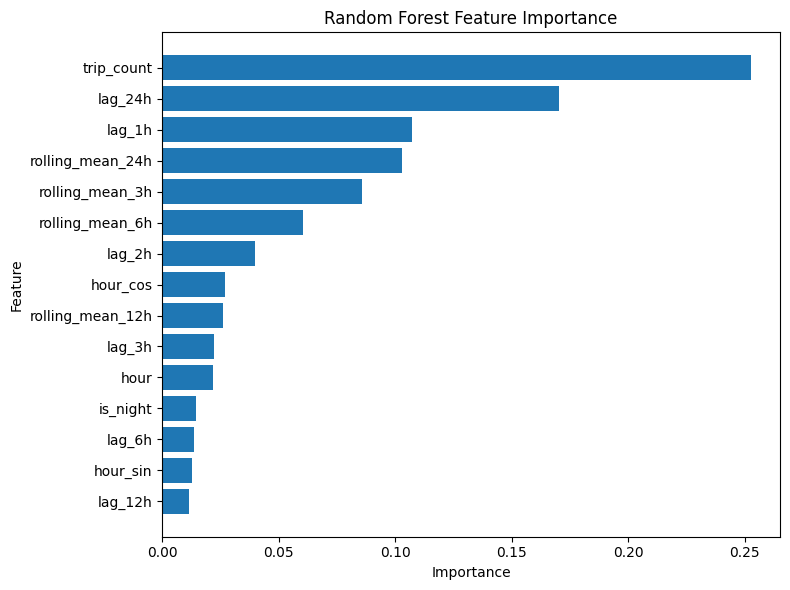

In [36]:
# Importing matplotlib

import matplotlib.pyplot as plt

# Plotting the 15 most important Random Forest features

plt.figure(figsize=(8, 6))
plt.barh(rf_feature_importance["Feature"].head(15)[::-1], rf_feature_importance["Importance"].head(15)[::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()

# Saving the figure

plt.savefig(figures_dir / "rf_feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

## Plotting Random Forest Actual vs Predicted Values

Comparing observed and predicted OD flows across a reproducible sample of unseen test observations.

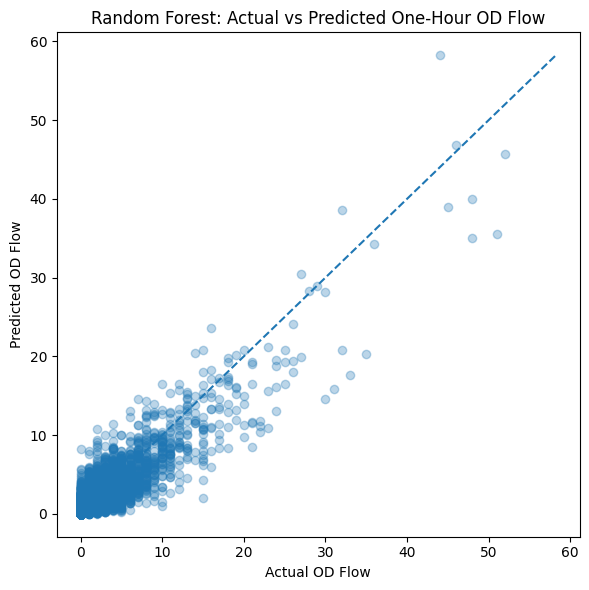

In [37]:
# Creating a sample for clearer plotting

plot_sample = rf_test_predictions_df.sample(n=min(10000, len(rf_test_predictions_df)), random_state=42)


# Creating the actual vs predicted plot

plt.figure(figsize=(6, 6))
plt.scatter(plot_sample["target_1h"], plot_sample["rf_prediction"], alpha=0.3)

max_value = max(plot_sample["target_1h"].max(), plot_sample["rf_prediction"].max())
plt.plot([0, max_value], [0, max_value], linestyle="--")

plt.xlabel("Actual OD Flow")
plt.ylabel("Predicted OD Flow")
plt.title("Random Forest: Actual vs Predicted One-Hour OD Flow")
plt.tight_layout()

plt.savefig(figures_dir / "rf_actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

Predictions generally follow the observed demand distribution, although larger errors are more visible for higher-demand observations.

## Plotting an Example OD Pair

This plot compares the observed and predicted one-hour-ahead OD flow for a representative Manhattan OD pair. It provides a qualitative assessment of how well the Random Forest model captures temporal changes in demand over the test period.

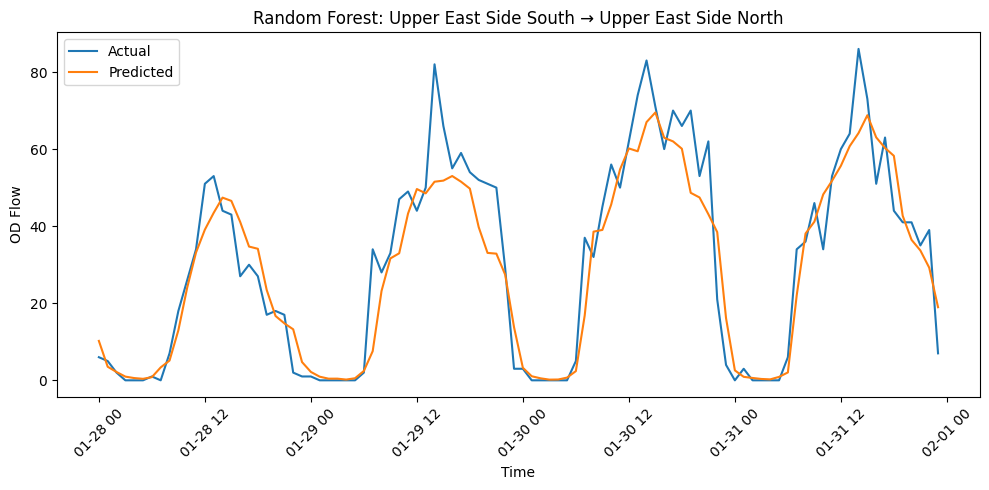

In [38]:
# Selecting the example OD pair

example_od_pair = "237_236"
example_od = rf_test_predictions_df[rf_test_predictions_df["od_pair"] == example_od_pair].copy()


# Plotting actual and predicted OD demand over time

plt.figure(figsize=(10, 5))
plt.plot(example_od["target_hour"], example_od["target_1h"], label="Actual")
plt.plot(example_od["target_hour"], example_od["rf_prediction"], label="Predicted")

plt.xlabel("Time")
plt.ylabel("OD Flow")
plt.title("Random Forest: Upper East Side South → Upper East Side North")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Saving the figure

plt.savefig(figures_dir / "rf_example_od_pair.png", dpi=300, bbox_inches="tight")

plt.show()

## Comparing the Persistence Baseline and Random Forest

In [39]:
# Comparing Persistence and Random Forest test performance

baseline_vs_rf = pd.DataFrame([persistence_test_metrics, rf_test_metrics])

display(baseline_vs_rf)

,Model,Split,MAE,RMSE,R2,WMAPE_%,MAPE_nonzero_%
0,Persistence Baseline,Test,0.962783,1.899151,0.620622,71.917376,76.890533
1,Random Forest,Test,0.829607,1.476327,0.770746,61.969452,55.214325


## Saving the Random Forest Performance Metrics

In [40]:
# Setting the metrics output path

metrics_path = reports_dir / "rf_metrics_1h_jan2024.csv"


# Saving the Random Forest performance results

rf_results.to_csv(metrics_path, index=False)

print("Saved metrics to:", metrics_path)

Saved metrics to: ..\Output\Reports\rf_metrics_1h_jan2024.csv


# LSTM Model

In [41]:
# Importing TensorFlow and Keras

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

C:\Users\nandh\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Setting LSTM Reproducibility

Setting fixed random seeds to improve consistency across repeated LSTM training runs.

In [42]:
# Setting reproducible random seeds

import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


## Preparing the LSTM Model Inputs

Selecting the one-hour-ahead target, 24-hour sequence length, and numerical input features.

In [43]:
# Setting the LSTM target and 24-hour historical window

lstm_target_col = "target_1h"
sequence_length = 24


# Selecting the 20 numerical features used at each timestep

lstm_feature_cols = [
    "trip_count",
    "lag_1h",
    "lag_2h",
    "lag_3h",
    "lag_6h",
    "lag_12h",
    "lag_24h",
    "rolling_mean_3h",
    "rolling_mean_6h",
    "rolling_mean_12h",
    "rolling_mean_24h",
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "is_weekend",
    "is_morning",
    "is_afternoon",
    "is_evening",
    "is_night"
]


# Checking the selected LSTM inputs

missing_lstm_features = [col for col in lstm_feature_cols if col not in od_model_data.columns]
non_numeric_lstm_features = [col for col in lstm_feature_cols if not pd.api.types.is_numeric_dtype(od_model_data[col])]

print("Target column:", lstm_target_col)
print("Sequence length:", sequence_length, "hours")
print("Number of LSTM features:", len(lstm_feature_cols))
print("Missing LSTM features:", missing_lstm_features)
print("Non-numeric LSTM features:", non_numeric_lstm_features)

Target column: target_1h
Sequence length: 24 hours
Number of LSTM features: 20
Missing LSTM features: []
Non-numeric LSTM features: []


## Scaling the LSTM Input Features

Standardising the input features using training data only to avoid data leakage.

In [44]:
# Importing the scaler

from sklearn.preprocessing import StandardScaler


# Creating the training mask

train_mask = od_model_data["data_split"] == "train"


# Fitting the scaler using training data only

lstm_scaler = StandardScaler()
lstm_scaler.fit(od_model_data.loc[train_mask, lstm_feature_cols])


# Transforming all LSTM input features

scaled_lstm_features = lstm_scaler.transform(
    od_model_data[lstm_feature_cols]
).astype(np.float32)


# Checking the scaled feature array

print("Scaled feature shape:", scaled_lstm_features.shape)
print("Scaled feature data type:", scaled_lstm_features.dtype)
print("Contains non-finite values:", not np.isfinite(scaled_lstm_features).all())

Scaled feature shape: (1738542, 20)
Scaled feature data type: float32
Contains non-finite values: False


## Reshaping the OD Time-Series Panel

Reshaping the data into OD pair × time × feature format for LSTM sequence creation.

In [45]:
# Sorting the data consistently by OD pair and time

od_model_data = od_model_data.sort_values(["od_pair", "pickup_hour"]).reset_index(drop=True)


# Transforming the sorted LSTM features

scaled_lstm_features = lstm_scaler.transform(od_model_data[lstm_feature_cols]).astype(np.float32)


# Setting the panel dimensions

n_od_pairs = od_model_data["od_pair"].nunique()
n_timesteps = od_model_data["pickup_hour"].nunique()
n_lstm_features = len(lstm_feature_cols)


# Reshaping the features and target into OD time-series panels

feature_panel = scaled_lstm_features.reshape(n_od_pairs, n_timesteps, n_lstm_features)
target_panel = od_model_data[lstm_target_col].to_numpy(dtype=np.float32).reshape(n_od_pairs, n_timesteps)


# Checking the panel shapes

print("OD pairs:", n_od_pairs)
print("Timesteps:", n_timesteps)
print("Feature panel shape:", feature_panel.shape)
print("Target panel shape:", target_panel.shape)

OD pairs: 2418
Timesteps: 719
Feature panel shape: (2418, 719, 20)
Target panel shape: (2418, 719)


## Creating the LSTM Sequence Endpoints

Identifying valid prediction points after a complete 24-hour historical sequence is available.

In [46]:
# Reshaping the temporal split labels

split_panel = od_model_data["data_split"].to_numpy().reshape(n_od_pairs, n_timesteps)

print("Same split structure for all OD pairs:", np.all(split_panel == split_panel[0]))

# Creating valid endpoints after a complete 24-hour history

endpoint_indices = np.arange(sequence_length - 1, n_timesteps)

train_endpoints = endpoint_indices[split_panel[0, endpoint_indices] == "train"]
val_endpoints = endpoint_indices[split_panel[0, endpoint_indices] == "validation"]
test_endpoints = endpoint_indices[split_panel[0, endpoint_indices] == "test"]


# Checking the sequence endpoints

print("Training endpoints:", len(train_endpoints))
print("Validation endpoints:", len(val_endpoints))
print("Test endpoints:", len(test_endpoints))
print("Total endpoints:", len(endpoint_indices))

Same split structure for all OD pairs: True
Training endpoints: 504
Validation endpoints: 96
Test endpoints: 96
Total endpoints: 696


## Creating the LSTM Sequence Generator

Generating 24-hour input sequences in batches to reduce memory usage during model training.

In [47]:
# Creating a memory-efficient sequence generator

class ODSequenceGenerator(tf.keras.utils.Sequence):

    def __init__(self, feature_panel, target_panel, end_indices, sequence_length, batch_size, shuffle=False, seed=42):
        super().__init__()

        self.feature_panel = feature_panel
        self.target_panel = target_panel
        self.end_indices = np.asarray(end_indices, dtype=np.int32)
        self.sequence_length = sequence_length
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.n_od_pairs = feature_panel.shape[0]
        self.n_endpoints = len(self.end_indices)

        self.sample_order = np.arange(self.n_od_pairs * self.n_endpoints, dtype=np.int32)
        self.window_offsets = np.arange(-(sequence_length - 1), 1, dtype=np.int32)

        self.random_generator = np.random.default_rng(seed)

        self.on_epoch_end()

    def __len__(self):
        return (len(self.sample_order) + self.batch_size - 1) // self.batch_size

    def __getitem__(self, batch_index):

        batch_start = batch_index * self.batch_size
        batch_end = min(batch_start + self.batch_size, len(self.sample_order))

        batch_sample_ids = self.sample_order[batch_start:batch_end]

        pair_indices = batch_sample_ids // self.n_endpoints
        endpoint_positions = batch_sample_ids % self.n_endpoints
        batch_end_indices = self.end_indices[endpoint_positions]

        time_indices = batch_end_indices[:, None] + self.window_offsets[None, :]

        X_batch = self.feature_panel[pair_indices[:, None], time_indices, :]
        y_batch = self.target_panel[pair_indices, batch_end_indices]

        return X_batch.astype(np.float32, copy=False), y_batch.astype(np.float32, copy=False)

    def on_epoch_end(self):
        if self.shuffle:
            self.random_generator.shuffle(self.sample_order)

## Creating the LSTM Data Generators

Creating separate batch generators for the training, validation, and test sequences.

In [48]:
# Creating the training, validation and test sequence generators

batch_size = 512

train_generator = ODSequenceGenerator(feature_panel, target_panel, train_endpoints, sequence_length, batch_size, shuffle=True, seed=SEED)
val_generator = ODSequenceGenerator(feature_panel, target_panel, val_endpoints, sequence_length, batch_size, shuffle=False, seed=SEED)
test_generator = ODSequenceGenerator(feature_panel, target_panel, test_endpoints, sequence_length, batch_size, shuffle=False, seed=SEED)

In [49]:
# Checking the sequence generators

X_batch, y_batch = train_generator[0]

print("Training batches:", len(train_generator))
print("Validation batches:", len(val_generator))
print("Test batches:", len(test_generator))
print("Input batch shape:", X_batch.shape)
print("Target batch shape:", y_batch.shape)
print("Non-finite inputs:", not np.isfinite(X_batch).all())
print("Non-finite targets:", not np.isfinite(y_batch).all())

Training batches: 2381
Validation batches: 454
Test batches: 454
Input batch shape: (512, 24, 20)
Target batch shape: (512,)
Non-finite inputs: False
Non-finite targets: False


## Checking Sequence and Target Alignment

Confirming that each 24-hour input sequence is correctly aligned with its corresponding one-hour-ahead OD-flow target.

In [50]:
# Selecting the first validation sequence

unique_od_pairs = od_model_data["od_pair"].drop_duplicates().to_numpy()

example_pair_index = 0
example_end_index = int(val_endpoints[0])
example_start_index = example_end_index - sequence_length + 1
example_od_pair = unique_od_pairs[example_pair_index]


# Retrieving the first validation batch

X_val_batch, y_val_batch = val_generator[0]


# Checking the stored and actual next-hour targets

stored_target = target_panel[example_pair_index, example_end_index]

next_hour_trip_count = od_model_data.loc[
    (od_model_data["od_pair"] == example_od_pair) &
    (od_model_data["pickup_hour"] == od_model_data["pickup_hour"].unique()[example_end_index] + pd.Timedelta(hours=1)),
    "trip_count"
].iloc[0]


# Displaying the alignment check

print("OD pair:", example_od_pair)
print("Sequence shape:", X_val_batch[0].shape)
print("Stored target:", stored_target)
print("Actual next-hour trip count:", next_hour_trip_count)
print("Targets match:", np.isclose(stored_target, next_hour_trip_count))
print("Generator target matches:", np.isclose(y_val_batch[0], stored_target))

OD pair: 100_100
Sequence shape: (24, 20)
Stored target: 0.0
Actual next-hour trip count: 0
Targets match: True
Generator target matches: True


## Building the LSTM Model

In [51]:
# Clearing any previously created TensorFlow models and resetting the seed

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)


# Building the LSTM model

lstm_model = Sequential([
    Input(shape=(sequence_length, n_lstm_features)),
    LSTM(64),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dense(1, activation="relu")
])


# Compiling the model

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)


# Displaying the model architecture

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,873 (93.25 KB)

 Trainable params: 23,873 (93.25 KB)

 Non-trainable params: 0 (0.00 B)

## Setting the LSTM Training Callbacks

Setting callbacks to save the best validation model, reduce the learning rate when improvement slows, and stop training when validation performance no longer improves.

In [52]:
# Setting the best-model output path

best_model_path = models_dir / "best_lstm_model_1h_jan2024.keras"


# Creating the training callbacks

callbacks = [
    ModelCheckpoint(best_model_path, monitor="val_loss", mode="min", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_loss", mode="min", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    tf.keras.callbacks.TerminateOnNaN()
]

print("Best model path:", best_model_path)
print("Number of callbacks:", len(callbacks))

Best model path: ..\Output\Models\best_lstm_model_1h_jan2024.keras
Number of callbacks: 4


## Checking the LSTM Training Pipeline

Testing a small number of validation batches to confirm that the sequence generator and LSTM model work correctly before full training.

In [53]:
# Checking the LSTM pipeline using two validation batches

pipeline_check = lstm_model.evaluate(
    val_generator,
    steps=2,
    verbose=1,
    return_dict=True
)

print("\nPipeline check results:")

for metric_name, metric_value in pipeline_check.items():
    print(f"{metric_name}: {metric_value:.6f}")

print("\nTraining pipeline checked successfully.")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.5901 - mae: 0.9378 - rmse: 1.4609 

Pipeline check results:
loss: 0.590073
mae: 0.937829
rmse: 1.460855

Training pipeline checked successfully.


## Training the LSTM Model

In [54]:
# Importing the timing library

import time


# Setting the maximum number of training epochs

max_epochs = 30


# Recording the training start time

training_start_time = time.perf_counter()


# Training the LSTM model

history = lstm_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=max_epochs,
    callbacks=callbacks,
    verbose=1
)


# Calculating the training time

training_time_minutes = (time.perf_counter() - training_start_time) / 60


# Displaying the training summary

print("\nLSTM training completed.")
print("Epochs completed:", len(history.history["loss"]))
print("Training time:", round(training_time_minutes, 2), "minutes")
print("Lowest validation loss:", round(min(history.history["val_loss"]), 6))

Epoch 1/30
2380/2381 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.5459 - mae: 0.8448 - rmse: 1.7622
Epoch 1: val_loss improved from None to 0.54989, saving model to ..\Output\Models\best_lstm_model_1h_jan2024.keras

Epoch 1: finished saving model to ..\Output\Models\best_lstm_model_1h_jan2024.keras
2381/2381 ━━━━━━━━━━━━━━━━━━━━ 107s 44ms/step - loss: 0.5112 - mae: 0.8086 - rmse: 1.6022 - val_loss: 0.5499 - val_mae: 0.8621 - val_rmse: 1.5702 - learning_rate: 0.0010
Epoch 2/30
2380/2381 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.4898 - mae: 0.7855 - rmse: 1.4891
Epoch 2: val_loss improved from 0.54989 to 0.54041, saving model to ..\Output\Models\best_lstm_model_1h_jan2024.keras

Epoch 2: finished saving model to ..\Output\Models\best_lstm_model_1h_jan2024.keras
2381/2381 ━━━━━━━━━━━━━━━━━━━━ 105s 44ms/step - loss: 0.4879 - mae: 0.7832 - rmse: 1.4760 - val_loss: 0.5404 - val_mae: 0.8468 - val_rmse: 1.5444 - learning_rate: 0.0010
Epoch 3/30
2380/2381 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - lo

The LSTM training stopped after 25 epochs, with the best validation performance obtained at epoch 20. Early stopping restored the model weights from this best-performing epoch, helping to limit overfitting.

## Visualising the LSTM Training History

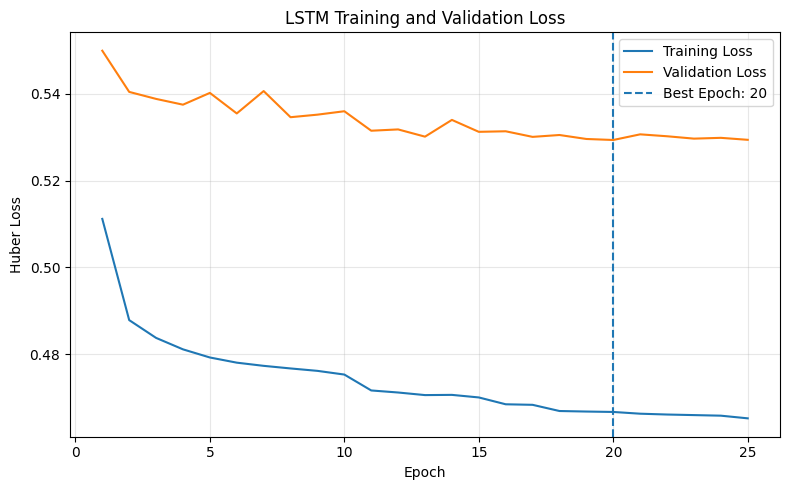

Best validation epoch: 20
Best validation loss: 0.529333
Saved training history plot to: ..\Output\Figures\lstm_training_validation_loss_1h_jan2024.png


In [55]:
# Creating the training history table

history_df = pd.DataFrame(history.history)
history_df["epoch"] = np.arange(1, len(history_df) + 1)


# Identifying the best validation epoch

best_epoch = int(history_df["val_loss"].idxmin() + 1)


# Setting the figure output path

training_history_path = figures_dir / "lstm_training_validation_loss_1h_jan2024.png"


# Plotting training and validation loss

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["loss"], label="Training Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch: {best_epoch}")

plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


# Saving and displaying the figure

plt.savefig(training_history_path, dpi=300, bbox_inches="tight")
plt.show()

print("Best validation epoch:", best_epoch)
print("Best validation loss:", round(history_df["val_loss"].min(), 6))
print("Saved training history plot to:", training_history_path)

The validation loss reached its minimum at epoch 20 before stabilising, while the training loss continued to decrease gradually. This supports the use of early stopping to retain the best-performing model and reduce overfitting.

## Evaluating the LSTM on the Validation Set

Generating one-hour-ahead validation predictions and evaluating them using the same metrics applied to the baseline models.

In [56]:
# Generating validation predictions

val_pred_lstm = lstm_model.predict(val_generator, verbose=1).reshape(-1)


# Creating validation targets in generator order

y_val_lstm = target_panel[:, val_endpoints].reshape(-1)


# Checking prediction and target shapes

print("Validation target shape:", y_val_lstm.shape)
print("Validation prediction shape:", val_pred_lstm.shape)


# Evaluating validation performance

lstm_val_metrics = evaluate_model(
    y_true=y_val_lstm,
    y_pred=val_pred_lstm,
    model_name="LSTM",
    split_name="Validation"
)

lstm_validation_results = pd.DataFrame([lstm_val_metrics])

display(lstm_validation_results)

454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step
Validation target shape: (232128,)
Validation prediction shape: (232128,)


,Model,Split,MAE,RMSE,R2,WMAPE_%,MAPE_nonzero_%
0,LSTM,Validation,0.83835,1.499189,0.792319,54.132114,53.513748


The LSTM achieves strong validation performance, improving on both the persistence and Random Forest baselines. This indicates that the 24-hour sequential input captures additional temporal information beyond the engineered lag and rolling features.

## Comparing Validation Performance

Comparing the LSTM with the persistence and Random Forest models using the same validation period and evaluation metrics.

In [57]:
# Combining the validation results

validation_comparison = pd.DataFrame([
    persistence_val_metrics,
    rf_val_metrics,
    lstm_val_metrics
])

display(validation_comparison)

,Model,Split,MAE,RMSE,R2,WMAPE_%,MAPE_nonzero_%
0,Persistence Baseline,Validation,1.076152,2.042905,0.614362,69.486980,76.154020
1,Random Forest,Validation,0.908040,1.596246,0.764559,58.631996,55.188335
2,LSTM,Validation,0.838350,1.499189,0.792319,54.132114,53.513748


The LSTM provides the strongest validation performance, achieving the lowest MAE and RMSE and the highest R² among the three models.

## Evaluating the LSTM on the Test Set

Loading the best validation model and evaluating it once on the unseen test period.

In [58]:
# Loading the best saved LSTM model

best_lstm_model = tf.keras.models.load_model(
    best_model_path,
    compile=False
)


# Generating test predictions

test_pred_lstm = best_lstm_model.predict(
    test_generator,
    verbose=1
).reshape(-1)


# Creating test targets in generator order

y_test_lstm = target_panel[:, test_endpoints].reshape(-1)


# Checking prediction validity

print("Test target shape:", y_test_lstm.shape)
print("Test prediction shape:", test_pred_lstm.shape)
print("Contains non-finite predictions:", not np.isfinite(test_pred_lstm).all())


# Evaluating the LSTM on the test set

lstm_test_metrics = evaluate_model(
    y_true=y_test_lstm,
    y_pred=test_pred_lstm,
    model_name="LSTM",
    split_name="Test"
)

lstm_test_results = pd.DataFrame([lstm_test_metrics])

display(lstm_test_results)

454/454 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step
Test target shape: (232128,)
Test prediction shape: (232128,)
Contains non-finite predictions: False


,Model,Split,MAE,RMSE,R2,WMAPE_%,MAPE_nonzero_%
0,LSTM,Test,0.761381,1.411329,0.790488,56.873165,54.129696


The LSTM achieves the strongest OD-level test performance, with lower MAE and RMSE and a higher R² than both the persistence and Random Forest models.

## Comparing Final Test Performance

Comparing the persistence baseline, Random Forest, and LSTM using the same unseen test period and evaluation metrics.

In [59]:
# Combining the final test results

test_comparison = pd.DataFrame([
    persistence_test_metrics,
    rf_test_metrics,
    lstm_test_metrics
])

display(test_comparison)

,Model,Split,MAE,RMSE,R2,WMAPE_%,MAPE_nonzero_%
0,Persistence Baseline,Test,0.962783,1.899151,0.620622,71.917376,76.890533
1,Random Forest,Test,0.829607,1.476327,0.770746,61.969452,55.214325
2,LSTM,Test,0.761381,1.411329,0.790488,56.873165,54.129696


## Saving the LSTM Evaluation Results


In [60]:
# Creating the LSTM metrics table

lstm_metrics = pd.DataFrame([
    lstm_val_metrics,
    lstm_test_metrics
])


# Creating the complete OD-level comparison table

final_model_comparison = pd.DataFrame([
    persistence_val_metrics,
    rf_val_metrics,
    lstm_val_metrics,
    persistence_test_metrics,
    rf_test_metrics,
    lstm_test_metrics
])


# Setting the output paths

lstm_metrics_path = reports_dir / "lstm_metrics_1h_jan2024.csv"
comparison_metrics_path = reports_dir / "od_model_comparison_1h_jan2024.csv"


# Saving the results

lstm_metrics.to_csv(lstm_metrics_path, index=False)
final_model_comparison.to_csv(comparison_metrics_path, index=False)


# Displaying the final comparison

display(final_model_comparison)

print("Saved LSTM metrics to:", lstm_metrics_path)
print("Saved model comparison to:", comparison_metrics_path)

,Model,Split,MAE,RMSE,R2,WMAPE_%,MAPE_nonzero_%
0,Persistence Baseline,Validation,1.076152,2.042905,0.614362,69.486980,76.154020
1,Random Forest,Validation,0.908040,1.596246,0.764559,58.631996,55.188335
2,LSTM,Validation,0.838350,1.499189,0.792319,54.132114,53.513748
3,Persistence Baseline,Test,0.962783,1.899151,0.620622,71.917376,76.890533
4,Random Forest,Test,0.829607,1.476327,0.770746,61.969452,55.214325
5,LSTM,Test,0.761381,1.411329,0.790488,56.873165,54.129696


Saved LSTM metrics to: ..\Output\Reports\lstm_metrics_1h_jan2024.csv
Saved model comparison to: ..\Output\Reports\od_model_comparison_1h_jan2024.csv


Across both validation and test periods, the LSTM achieves the strongest overall OD-level forecasting performance, while Random Forest consistently improves upon the persistence baseline.

## Creating and Saving the LSTM Test Predictions


In [61]:
# Creating OD-pair and endpoint indices in prediction order

test_pair_indices = np.repeat(np.arange(n_od_pairs), len(test_endpoints))
test_time_indices = np.tile(test_endpoints, n_od_pairs)


# Creating one metadata row for each OD pair

pair_metadata = (
    od_model_data[
        ["od_pair", "PULocationID", "DOLocationID", "PU_Zone", "DO_Zone"]
    ]
    .drop_duplicates(subset="od_pair")
    .set_index("od_pair")
    .loc[unique_od_pairs]
    .reset_index()
)


# Creating the LSTM test prediction table

lstm_test_predictions = pd.DataFrame({
    "sequence_end_time": pd.to_datetime(
        od_model_data["pickup_hour"].unique()[test_time_indices]
    ),
    "prediction_hour": pd.to_datetime(
        od_model_data["pickup_hour"].unique()[test_time_indices]
    ) + pd.Timedelta(hours=1),
    "od_pair": unique_od_pairs[test_pair_indices],
    "PULocationID": pair_metadata["PULocationID"].to_numpy()[test_pair_indices],
    "DOLocationID": pair_metadata["DOLocationID"].to_numpy()[test_pair_indices],
    "PU_Zone": pair_metadata["PU_Zone"].to_numpy()[test_pair_indices],
    "DO_Zone": pair_metadata["DO_Zone"].to_numpy()[test_pair_indices],
    "target_1h": y_test_lstm,
    "lstm_pred_1h": test_pred_lstm
})


# Creating rounded predictions and absolute error

lstm_test_predictions["lstm_pred_1h_rounded"] = np.rint(
    lstm_test_predictions["lstm_pred_1h"]
).astype(int)

lstm_test_predictions["absolute_error"] = np.abs(
    lstm_test_predictions["target_1h"]
    - lstm_test_predictions["lstm_pred_1h"]
)


# Checking and saving the prediction table

print("Test prediction table shape:", lstm_test_predictions.shape)
display(lstm_test_predictions.head())

lstm_predictions_path = reports_dir / "lstm_test_predictions_1h_jan2024.csv"
lstm_test_predictions.to_csv(lstm_predictions_path, index=False)

print("Saved LSTM test predictions to:", lstm_predictions_path)

Test prediction table shape: (232128, 11)


,sequence_end_time,prediction_hour,od_pair,PULocationID,DOLocationID,PU_Zone,DO_Zone,target_1h,lstm_pred_1h,lstm_pred_1h_rounded,absolute_error
0,2024-01-27 23:00:00,2024-01-28 00:00:00,100_100,100,100,Garment District,Garment District,1.0,0.693537,1,0.306463
1,2024-01-28 00:00:00,2024-01-28 01:00:00,100_100,100,100,Garment District,Garment District,0.0,0.417936,0,0.417936
2,2024-01-28 01:00:00,2024-01-28 02:00:00,100_100,100,100,Garment District,Garment District,2.0,0.264676,0,1.735324
3,2024-01-28 02:00:00,2024-01-28 03:00:00,100_100,100,100,Garment District,Garment District,1.0,0.289666,0,0.710334
4,2024-01-28 03:00:00,2024-01-28 04:00:00,100_100,100,100,Garment District,Garment District,1.0,0.231808,0,0.768193


Saved LSTM test predictions to: ..\Output\Reports\lstm_test_predictions_1h_jan2024.csv


## Saving the LSTM Feature Scaler


In [62]:
# Setting the scaler output path

lstm_scaler_path = models_dir / "lstm_scaler_1h_jan2024.joblib"


# Saving the fitted LSTM scaler

joblib.dump(lstm_scaler, lstm_scaler_path)

print("Saved LSTM scaler to:", lstm_scaler_path)

Saved LSTM scaler to: ..\Output\Models\lstm_scaler_1h_jan2024.joblib


## Checking the Saved LSTM Model

In [63]:
# Checking the saved best LSTM model

print("Best LSTM model exists:", best_model_path.exists())
print("Best LSTM model path:", best_model_path)

Best LSTM model exists: True
Best LSTM model path: ..\Output\Models\best_lstm_model_1h_jan2024.keras


## Plotting LSTM Actual vs Predicted Values

Comparing observed and predicted OD flows across a reproducible sample of unseen test observations.

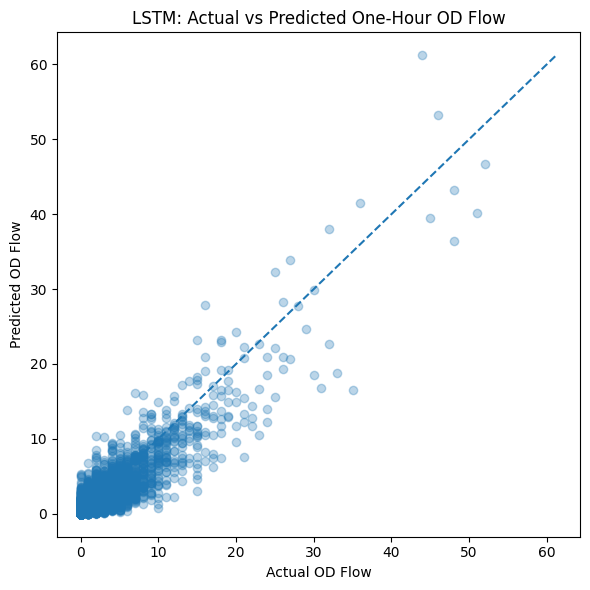

In [64]:
# Creating a reproducible sample for clearer plotting

lstm_plot_sample = lstm_test_predictions.sample(
    n=min(10000, len(lstm_test_predictions)),
    random_state=42
)


# Creating the actual vs predicted plot

plt.figure(figsize=(6, 6))
plt.scatter(
    lstm_plot_sample["target_1h"],
    lstm_plot_sample["lstm_pred_1h"],
    alpha=0.3
)

max_value = max(
    lstm_plot_sample["target_1h"].max(),
    lstm_plot_sample["lstm_pred_1h"].max()
)

plt.plot([0, max_value], [0, max_value], linestyle="--")

plt.xlabel("Actual OD Flow")
plt.ylabel("Predicted OD Flow")
plt.title("LSTM: Actual vs Predicted One-Hour OD Flow")
plt.tight_layout()


# Saving and displaying the figure

plt.savefig(
    figures_dir / "lstm_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Plotting an Example OD Pair for the LSTM

Comparing observed and predicted one-hour-ahead demand over time for the same representative Manhattan OD pair used in the Random Forest analysis.

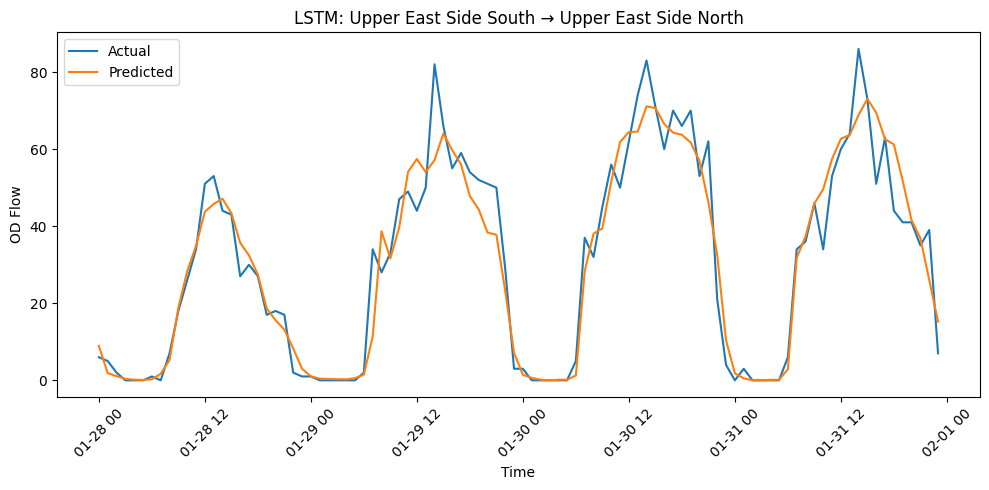

In [65]:
# Selecting the same representative OD pair

example_od_pair = "237_236"

lstm_example_od = lstm_test_predictions[
    lstm_test_predictions["od_pair"] == example_od_pair
].copy()


# Plotting actual and predicted OD demand over time

plt.figure(figsize=(10, 5))

plt.plot(
    lstm_example_od["prediction_hour"],
    lstm_example_od["target_1h"],
    label="Actual"
)

plt.plot(
    lstm_example_od["prediction_hour"],
    lstm_example_od["lstm_pred_1h"],
    label="Predicted"
)

plt.xlabel("Time")
plt.ylabel("OD Flow")
plt.title("LSTM: Upper East Side South → Upper East Side North")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()


# Saving and displaying the figure

plt.savefig(
    figures_dir / "lstm_example_od_pair.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The LSTM captures the overall temporal pattern and recurring demand peaks for this high-demand OD pair, although some sharp peak magnitudes remain underestimated.

## Calculating LSTM Performance Improvements

Calculating the percentage improvement in MAE and RMSE achieved by the LSTM relative to the persistence baseline and Random Forest.

In [66]:
# Calculating LSTM improvements over the persistence baseline and Random Forest

improvement_results = pd.DataFrame({
    "Comparison": ["LSTM vs Persistence", "LSTM vs Random Forest"],
    "MAE_Improvement_%": [
        (persistence_test_metrics["MAE"] - lstm_test_metrics["MAE"]) / persistence_test_metrics["MAE"] * 100,
        (rf_test_metrics["MAE"] - lstm_test_metrics["MAE"]) / rf_test_metrics["MAE"] * 100
    ],
    "RMSE_Improvement_%": [
        (persistence_test_metrics["RMSE"] - lstm_test_metrics["RMSE"]) / persistence_test_metrics["RMSE"] * 100,
        (rf_test_metrics["RMSE"] - lstm_test_metrics["RMSE"]) / rf_test_metrics["RMSE"] * 100
    ]
})

display(improvement_results.round(2))

,Comparison,MAE_Improvement_%,RMSE_Improvement_%
0,LSTM vs Persistence,20.92,25.69
1,LSTM vs Random Forest,8.22,4.40


The LSTM reduces MAE by approximately 20.9% relative to persistence and 8.2% relative to Random Forest. The corresponding RMSE reductions are approximately 25.7% and 4.4%, confirming the LSTM as the strongest OD-level model.

# OD-Level GAT-GRU Model

## Loading and Checking the Taxi-Zone Spatial Data


In [73]:
# Importing library

import geopandas as gpd
from sklearn.neighbors import NearestNeighbors
import networkx as nx


# Setting the taxi-zone shapefile path

taxi_zones_path = (
    project_dir
    / "Data"
    / "Spatial"
    / "taxi_zones"
    / "taxi_zones.shp"
)


# Loading the taxi-zone spatial boundaries

taxi_zones = gpd.read_file(taxi_zones_path)


# Checking the spatial dataset structure

print("Taxi-zone shapefile exists:", taxi_zones_path.exists())
print("Taxi-zone shape:", taxi_zones.shape)
print("Coordinate reference system:", taxi_zones.crs)

print("\nMissing geometries:", taxi_zones.geometry.isna().sum())
print("Empty geometries:", taxi_zones.geometry.is_empty.sum())
print("Invalid geometries:", (~taxi_zones.geometry.is_valid).sum())
print("Duplicate LocationID values:", taxi_zones["LocationID"].duplicated().sum())

print("\nGeometry types:")
display(taxi_zones.geometry.geom_type.value_counts())

Taxi-zone shapefile exists: True
Taxi-zone shape: (263, 7)
Coordinate reference system: EPSG:2263

Missing geometries: 0
Empty geometries: 0
Invalid geometries: 0
Duplicate LocationID values: 0

Geometry types:


Polygon         240
MultiPolygon     23
Name: count, dtype: int64

## Selecting the Spatial Zones Used by the OD Network
Selecting the Manhattan taxi-zone geometries represented by the retained OD pairs to define the spatial coverage required for graph construction.

In [68]:
# Selecting all Manhattan taxi-zone geometries

manhattan_zones = taxi_zones[
    taxi_zones["borough"].eq("Manhattan")
].copy()


# Identifying every taxi zone used as either an origin or destination in the final OD network

selected_zone_ids = set(
    pair_info["PULocationID"]
).union(
    set(pair_info["DOLocationID"])
)


# Selecting geometries required by the OD graph

selected_zone_geometries = manhattan_zones[
    manhattan_zones["LocationID"].isin(selected_zone_ids)
].copy()


# Checking whether every selected zone has a matching geometry

matched_zone_ids = set(
    selected_zone_geometries["LocationID"]
)

unmatched_selected_zones = (
    selected_zone_ids - matched_zone_ids
)


# Identifying Manhattan zones not represented in the retained OD network

unused_manhattan_zones = (
    manhattan_zones[
        ~manhattan_zones["LocationID"].isin(selected_zone_ids)
    ][["LocationID", "zone"]]
    .sort_values("LocationID")
)


# Checking the spatial coverage

print("Total Manhattan zones:", len(manhattan_zones))
print("Zones used by selected OD pairs:", len(selected_zone_ids))
print("Matched selected-zone geometries:", len(selected_zone_geometries))
print("Unmatched selected zones:", len(unmatched_selected_zones))
print("Unused Manhattan zones:", len(unused_manhattan_zones))

display(unused_manhattan_zones)

Total Manhattan zones: 69
Zones used by selected OD pairs: 61
Matched selected-zone geometries: 61
Unmatched selected zones: 0
Unused Manhattan zones: 8


,LocationID,zone
102,103,Governor's Island/Ellis Island/Liberty Island
103,104,Governor's Island/Ellis Island/Liberty Island
104,105,Governor's Island/Ellis Island/Liberty Island
119,120,Highbridge Park
127,128,Inwood Hill Park
152,153,Marble Hill
193,194,Randalls Island
201,202,Roosevelt Island


The final OD network uses 61 Manhattan taxi zones, and all selected zones have matching spatial geometry.

## Checking the Selected OD-Pair Structure


In [122]:
# Creating the final OD-pair table with training-only activity information

gat_selected_pairs = pair_info.merge(
    od_pair_activity[
        [
            "od_pair",
            "training_active_hours",
            "training_total_trips",
            "training_activity_ratio"
        ]
    ],
    on="od_pair",
    how="left",
    validate="one_to_one"
)


# Checking missing values and duplicate OD pairs

selected_pair_missing_values = (
    gat_selected_pairs.isna().sum().sum()
)

duplicate_od_pairs = (
    gat_selected_pairs["od_pair"].duplicated().sum()
)


# Identifying origin and destination zones

origin_zone_ids = set(
    gat_selected_pairs["PULocationID"].unique()
)

destination_zone_ids = set(
    gat_selected_pairs["DOLocationID"].unique()
)

all_selected_zone_ids = (
    origin_zone_ids | destination_zone_ids
)

origin_only_zone_ids = (
    origin_zone_ids - destination_zone_ids
)

destination_only_zone_ids = (
    destination_zone_ids - origin_zone_ids
)


# Counting OD pairs where origin and destination are the same zone

within_zone_od_pairs = (
    gat_selected_pairs["PULocationID"]
    == gat_selected_pairs["DOLocationID"]
).sum()


# Creating a lookup for destination-only zone names

zone_name_lookup = pd.concat(
    [
        gat_selected_pairs[
            ["PULocationID", "PU_Zone"]
        ].rename(
            columns={
                "PULocationID": "LocationID",
                "PU_Zone": "zone"
            }
        ),
        gat_selected_pairs[
            ["DOLocationID", "DO_Zone"]
        ].rename(
            columns={
                "DOLocationID": "LocationID",
                "DO_Zone": "zone"
            }
        )
    ],
    ignore_index=True
).drop_duplicates("LocationID")


destination_only_zones = (
    zone_name_lookup[
        zone_name_lookup["LocationID"].isin(
            destination_only_zone_ids
        )
    ]
    .sort_values("LocationID")
    .reset_index(drop=True)
)


# Showing the OD-pair checks

print("Selected OD pairs:", len(gat_selected_pairs))
print("Missing values:", int(selected_pair_missing_values))
print("Duplicated OD pairs:", int(duplicate_od_pairs))

print("\nUnique origin zones:", len(origin_zone_ids))
print("Unique destination zones:", len(destination_zone_ids))
print("Unique zones overall:", len(all_selected_zone_ids))

print("\nOrigin-only zones:", len(origin_only_zone_ids))
print("Destination-only zones:", len(destination_only_zone_ids))
print("Within-zone OD pairs:", int(within_zone_od_pairs))

print(
    "\nMinimum active training hours:",
    gat_selected_pairs["training_active_hours"].min()
)

print(
    "Maximum active training hours:",
    gat_selected_pairs["training_active_hours"].max()
)

print(
    "Total retained training trips:",
    gat_selected_pairs["training_total_trips"].sum()
)

display(destination_only_zones)

Selected OD pairs: 2418
Missing values: 0
Duplicated OD pairs: 0

Unique origin zones: 58
Unique destination zones: 61
Unique zones overall: 61

Origin-only zones: 0
Destination-only zones: 3
Within-zone OD pairs: 52

Minimum active training hours: 56
Maximum active training hours: 534
Total retained training trips: 1730219


,LocationID,zone
0,12,Battery Park
1,127,Inwood
2,243,Washington Heights North


The final OD network contains 2,418 directed OD pairs across 61 taxi zones. Three zones appear only as destinations, which is valid because OD flows are directional.

## Creating the Graph Node Table

Assigning a fixed graph node index to each selected OD pair for graph construction.

In [70]:
# Sorting OD pairs by pickup and drop-off location IDs
node_table = (
    gat_selected_pairs
    .sort_values(["PULocationID", "DOLocationID"])
    .reset_index(drop=True)
    .copy()
)


# Assigning one graph node index to each OD pair
node_table.insert(
    0,
    "node_index",
    np.arange(len(node_table), dtype=np.int32)
)


# Checking node mapping
duplicate_node_indices = node_table["node_index"].duplicated().sum()
duplicate_node_od_pairs = node_table["od_pair"].duplicated().sum()

continuous_node_indices = np.array_equal(
    node_table["node_index"].to_numpy(),
    np.arange(len(node_table), dtype=np.int32)
)


# Checking that OD labels match the location IDs
reconstructed_od_pairs = (
    node_table["PULocationID"].astype(str)
    + "_"
    + node_table["DOLocationID"].astype(str)
)

inconsistent_node_labels = (
    node_table["od_pair"] != reconstructed_od_pairs
).sum()


# Showing the checks
print("Graph nodes:", len(node_table))
print("Minimum node index:", node_table["node_index"].min())
print("Maximum node index:", node_table["node_index"].max())
print("Duplicate node indices:", int(duplicate_node_indices))
print("Duplicate node OD pairs:", int(duplicate_node_od_pairs))
print("Continuous node indices:", continuous_node_indices)
print("Inconsistent node labels:", int(inconsistent_node_labels))


# Previewing the node table
display(
    node_table[
        [
            "node_index",
            "od_pair",
            "PULocationID",
            "DOLocationID",
            "PU_Zone",
            "DO_Zone",
            "training_active_hours",
            "training_total_trips"
        ]
    ].head(10)
)

Graph nodes: 2418
Minimum node index: 0
Maximum node index: 2417
Duplicate node indices: 0
Duplicate node OD pairs: 0
Continuous node indices: True
Inconsistent node labels: 0


,node_index,od_pair,PULocationID,DOLocationID,PU_Zone,DO_Zone,training_active_hours,training_total_trips
0,0,4_79,4,79,Alphabet City,East Village,95,167
1,1,4_107,4,107,Alphabet City,Gramercy,83,122
2,2,4_114,4,114,Alphabet City,Greenwich Village South,85,118
3,3,4_148,4,148,Alphabet City,Lower East Side,71,103
4,4,4_249,4,249,Alphabet City,West Village,68,90
5,5,13_12,13,12,Battery Park City,Battery Park,64,79
6,6,13_13,13,13,Battery Park City,Battery Park City,162,222
7,7,13_45,13,45,Battery Park City,Chinatown,92,113
8,8,13_48,13,48,Battery Park City,Clinton East,183,275
9,9,13_50,13,50,Battery Park City,Clinton West,96,116


The graph contains 2,418 nodes, with one unique node representing each retained directed OD pair.

## Creating Taxi-Zone Centroids

Calculating the centroid of each selected taxi zone and adding the origin and destination coordinates to each OD graph node.

In [71]:
# Selecting geometries used by the retained OD pairs
zone_centroids = selected_zone_geometries[
    ["LocationID", "zone", "geometry"]
].copy()


# Calculating taxi-zone centroids
zone_centroids["centroid_geometry"] = (
    zone_centroids.geometry.centroid
)

# Extracting centroid coordinates
zone_centroids["centroid_x"] = zone_centroids["centroid_geometry"].x
zone_centroids["centroid_y"] = zone_centroids["centroid_geometry"].y


# Creating origin centroid information
origin_centroids = zone_centroids[
    ["LocationID", "centroid_x", "centroid_y"]
].rename(
    columns={
        "LocationID": "PULocationID",
        "centroid_x": "origin_x",
        "centroid_y": "origin_y"
    }
)


# Creating destination centroid information
destination_centroids = zone_centroids[
    ["LocationID", "centroid_x", "centroid_y"]
].rename(
    columns={
        "LocationID": "DOLocationID",
        "centroid_x": "destination_x",
        "centroid_y": "destination_y"
    }
)


# Adding origin coordinates to each OD node
node_table = node_table.merge(
    origin_centroids,
    on="PULocationID",
    how="left",
    validate="many_to_one"
)


# Adding destination coordinates to each OD node
node_table = node_table.merge(
    destination_centroids,
    on="DOLocationID",
    how="left",
    validate="many_to_one"
)


# Checking the coordinate joins
missing_origin_coordinates = (
    node_table[["origin_x", "origin_y"]]
    .isna()
    .any(axis=1)
    .sum()
)

missing_destination_coordinates = (
    node_table[["destination_x", "destination_y"]]
    .isna()
    .any(axis=1)
    .sum()
)


print("Taxi-zone centroid records:", len(zone_centroids))
print("Graph node records:", len(node_table))
print("Missing origin coordinates:", int(missing_origin_coordinates))
print("Missing destination coordinates:", int(missing_destination_coordinates))


# Previewing the spatial node information
display(
    node_table[
        [
            "node_index",
            "od_pair",
            "PU_Zone",
            "DO_Zone",
            "origin_x",
            "origin_y",
            "destination_x",
            "destination_y"
        ]
    ].head()
)

Taxi-zone centroid records: 61
Graph node records: 2418
Missing origin coordinates: 0
Missing destination coordinates: 0


,node_index,od_pair,PU_Zone,DO_Zone,origin_x,origin_y,destination_x,destination_y
0,0,4_79,Alphabet City,East Village,990633.980641,202959.782391,988147.657991,204368.501875
1,1,4_107,Alphabet City,Gramercy,990633.980641,202959.782391,988669.590715,207721.845998
2,2,4_114,Alphabet City,Greenwich Village South,990633.980641,202959.782391,984976.121744,204630.607988
3,3,4_148,Alphabet City,Lower East Side,990633.980641,202959.782391,986773.546092,201205.264892
4,4,4_249,Alphabet City,West Village,990633.980641,202959.782391,983453.224648,206902.407995


All 2,418 OD nodes have valid origin and destination centroid coordinates for creating the spatial graph.

## Checking Candidate Neighbour Counts

Comparing different nearest-neighbour settings to choose a suitable graph structure for the OD routes.

In [74]:
# Creating the 4-dimensional spatial representation of each OD route
route_coordinates = node_table[
    [
        "origin_x",
        "origin_y",
        "destination_x",
        "destination_y"
    ]
].to_numpy(dtype=np.float64)


# Checking the route coordinates
assert np.isfinite(route_coordinates).all(), (
    "Non-finite route coordinates were found."
)


# Setting candidate nearest-neighbour values
candidate_k_values = [4, 6, 8, 10, 12]


# Fitting the nearest-neighbour model
neighbour_model = NearestNeighbors(
    n_neighbors=max(candidate_k_values) + 1,
    metric="euclidean"
)

neighbour_model.fit(route_coordinates)


# Finding the nearest routes for each node
neighbour_distances, neighbour_positions = (
    neighbour_model.kneighbors(route_coordinates)
)


# Keeping graph node indices
node_indices = node_table["node_index"].to_numpy()


# Creating an undirected K-nearest-neighbour edge set
def create_knn_edge_set(k):

    edge_set = set()

    for node_position in range(len(node_indices)):

        source_node = int(node_indices[node_position])

        # Skipping the first neighbour because it is the node itself
        neighbour_rows = neighbour_positions[
            node_position,
            1:k + 1
        ]

        for neighbour_position in neighbour_rows:

            target_node = int(
                node_indices[neighbour_position]
            )

            # Keeping each undirected edge only once
            edge = tuple(
                sorted((source_node, target_node))
            )

            edge_set.add(edge)

    return edge_set


# Comparing candidate graph structures
candidate_results = []

for k in candidate_k_values:

    candidate_edges = create_knn_edge_set(k)

    candidate_graph = nx.Graph()
    candidate_graph.add_nodes_from(node_indices.tolist())
    candidate_graph.add_edges_from(candidate_edges)

    node_degrees = np.array(
        [degree for _, degree in candidate_graph.degree()]
    )

    candidate_results.append({
        "k_neighbours": k,
        "nodes": candidate_graph.number_of_nodes(),
        "undirected_edges": candidate_graph.number_of_edges(),
        "connected_components": nx.number_connected_components(
            candidate_graph
        ),
        "isolated_nodes": len(
            list(nx.isolates(candidate_graph))
        ),
        "minimum_degree": int(node_degrees.min()),
        "median_degree": float(np.median(node_degrees)),
        "maximum_degree": int(node_degrees.max())
    })


# Creating the comparison table
candidate_graph_summary = pd.DataFrame(candidate_results)

display(candidate_graph_summary)

,k_neighbours,nodes,undirected_edges,connected_components,isolated_nodes,minimum_degree,median_degree,maximum_degree
0,4,2418,5851,6,0,4,5.0,10
1,6,2418,8701,1,0,6,7.0,14
2,8,2418,11552,1,0,8,9.0,18
3,10,2418,14352,1,0,10,11.0,22
4,12,2418,17159,1,0,12,14.0,26


K=4 produces a disconnected graph, while K=6 and above create one connected network. K=8 is selected as a balanced choice that keeps the graph connected without making it unnecessarily dense.

## Creating the Final OD Graph

Creating the final K=8 graph and checking its connectivity and node degrees.

In [75]:
# Setting the selected number of neighbours
SELECTED_K = 8


# Creating the final K=8 edge set
selected_edge_set = create_knn_edge_set(SELECTED_K)


# Creating the final undirected OD graph
od_graph = nx.Graph()

od_graph.add_nodes_from(node_indices.tolist())
od_graph.add_edges_from(selected_edge_set)


# Calculating node degrees
graph_degrees = np.array(
    [degree for _, degree in od_graph.degree()],
    dtype=np.int32
)


# Checking graph connectivity
connected_components = nx.number_connected_components(od_graph)
isolated_nodes = list(nx.isolates(od_graph))
graph_is_connected = nx.is_connected(od_graph)


# Showing the final graph structure
print("Selected neighbours per node:", SELECTED_K)
print("Graph nodes:", od_graph.number_of_nodes())
print("Undirected graph edges:", od_graph.number_of_edges())
print("Connected components:", connected_components)
print("Isolated nodes:", len(isolated_nodes))
print("Graph is connected:", graph_is_connected)

print("\nMinimum node degree:", graph_degrees.min())
print("Median node degree:", np.median(graph_degrees))
print("Mean node degree:", graph_degrees.mean())
print("Maximum node degree:", graph_degrees.max())

Selected neighbours per node: 8
Graph nodes: 2418
Undirected graph edges: 11552
Connected components: 1
Isolated nodes: 0
Graph is connected: True

Minimum node degree: 8
Median node degree: 9.0
Mean node degree: 9.555004135649297
Maximum node degree: 18


## Checking Graph Edge Similarity

Checking whether the K=8 graph connects OD routes with similar origin and destination locations.

In [76]:
# Creating the graph edge table
edge_table = pd.DataFrame(
    sorted(selected_edge_set),
    columns=["source_node", "target_node"]
)

# Creating a node lookup
node_lookup = node_table.set_index("node_index")


# Adding source-node information
edge_table["source_od_pair"] = edge_table["source_node"].map(
    node_lookup["od_pair"]
)
edge_table["source_origin_id"] = edge_table["source_node"].map(
    node_lookup["PULocationID"]
)
edge_table["source_destination_id"] = edge_table["source_node"].map(
    node_lookup["DOLocationID"]
)


# Adding target-node information
edge_table["target_od_pair"] = edge_table["target_node"].map(
    node_lookup["od_pair"]
)
edge_table["target_origin_id"] = edge_table["target_node"].map(
    node_lookup["PULocationID"]
)
edge_table["target_destination_id"] = edge_table["target_node"].map(
    node_lookup["DOLocationID"]
)


# Retrieving source coordinates
source_origin_x = edge_table["source_node"].map(node_lookup["origin_x"])
source_origin_y = edge_table["source_node"].map(node_lookup["origin_y"])
source_destination_x = edge_table["source_node"].map(node_lookup["destination_x"])
source_destination_y = edge_table["source_node"].map(node_lookup["destination_y"])

# Retrieving target coordinates
target_origin_x = edge_table["target_node"].map(node_lookup["origin_x"])
target_origin_y = edge_table["target_node"].map(node_lookup["origin_y"])
target_destination_x = edge_table["target_node"].map(node_lookup["destination_x"])
target_destination_y = edge_table["target_node"].map(node_lookup["destination_y"])


# Calculating origin and destination distances
edge_table["origin_distance_feet"] = np.sqrt(
    (source_origin_x - target_origin_x) ** 2
    + (source_origin_y - target_origin_y) ** 2
)

edge_table["destination_distance_feet"] = np.sqrt(
    (source_destination_x - target_destination_x) ** 2
    + (source_destination_y - target_destination_y) ** 2
)


# Calculating combined route distance
edge_table["route_distance_feet"] = np.sqrt(
    edge_table["origin_distance_feet"] ** 2
    + edge_table["destination_distance_feet"] ** 2
)

edge_table["route_distance_miles"] = (
    edge_table["route_distance_feet"] / 5280
)


# Identifying the spatial relationship
shared_origin = (
    edge_table["source_origin_id"]
    == edge_table["target_origin_id"]
)

shared_destination = (
    edge_table["source_destination_id"]
    == edge_table["target_destination_id"]
)

edge_table["edge_relationship"] = np.select(
    [shared_origin, shared_destination],
    ["Shared origin", "Shared destination"],
    default="Nearby origins and destinations"
)


# Checking edge-table quality
self_loops = (
    edge_table["source_node"]
    == edge_table["target_node"]
).sum()

duplicate_edges = edge_table.duplicated(
    subset=["source_node", "target_node"]
).sum()

missing_edge_values = edge_table.isna().sum().sum()


print("Edge-table rows:", len(edge_table))
print("Graph edges:", od_graph.number_of_edges())
print("Self-loop edges:", int(self_loops))
print("Duplicated edges:", int(duplicate_edges))
print("Missing edge values:", int(missing_edge_values))


# Summarising relationship types
relationship_summary = (
    edge_table["edge_relationship"]
    .value_counts()
    .rename_axis("relationship")
    .reset_index(name="edges")
)

print("\nSpatial relationship types:")
display(relationship_summary)


# Summarising route distances
print("Route-similarity distance summary in miles:")
display(edge_table["route_distance_miles"].describe())


# Previewing example graph connections
display(
    edge_table[
        [
            "source_node",
            "source_od_pair",
            "target_node",
            "target_od_pair",
            "edge_relationship",
            "route_distance_miles"
        ]
    ].head(10)
)

Edge-table rows: 11552
Graph edges: 11552
Self-loop edges: 0
Duplicated edges: 0
Missing edge values: 0

Spatial relationship types:


,relationship,edges
0,Shared destination,4055
1,Nearby origins and destinations,3792
2,Shared origin,3705


Route-similarity distance summary in miles:


count    11552.000000
mean         0.560500
std          0.183737
min          0.214490
25%          0.441216
50%          0.546242
75%          0.652998
max          2.630579
Name: route_distance_miles, dtype: float64

,source_node,source_od_pair,target_node,target_od_pair,edge_relationship,route_distance_miles
0,0,4_79,1,4_107,Shared origin,0.642750
1,0,4_79,2,4_114,Shared origin,0.602718
2,0,4_79,3,4_148,Shared origin,0.653183
3,0,4_79,365,79_4,Nearby origins and destinations,0.765409
4,0,4_79,376,79_79,Shared destination,0.541226
5,0,4_79,382,79_113,Nearby origins and destinations,0.776476
6,0,4_79,1680,224_79,Shared destination,0.557084
7,0,4_79,1852,232_79,Shared destination,0.698890
8,1,4_107,381,79_107,Shared destination,0.541226
9,1,4_107,385,79_137,Nearby origins and destinations,0.715875


## Visualising the Graph Degree Distribution

Checking how many connections each OD node has in the final K=8 graph.

Node-degree summary:


count    2418.000000
mean        9.555004
std         1.690733
min         8.000000
25%         8.000000
50%         9.000000
75%        10.000000
max        18.000000
Name: degree, dtype: float64

Most connected OD-pair nodes:


,node_index,degree,od_pair,PU_Zone,DO_Zone
2401,2401,18,263_186,Yorkville West,Penn Station/Madison Sq West
2405,2405,18,263_230,Yorkville West,Times Sq/Theatre District
940,940,17,141_186,Lenox Hill West,Penn Station/Madison Sq West
1582,1582,17,186_141,Penn Station/Madison Sq West,Lenox Hill West
1616,1616,17,186_263,Penn Station/Madison Sq West,Yorkville West
1801,1801,17,230_261,Times Sq/Theatre District,World Trade Center
1803,1803,17,230_263,Times Sq/Theatre District,Yorkville West
1997,1997,17,236_186,Upper East Side North,Penn Station/Madison Sq West
719,719,16,114_141,Greenwich Village South,Lenox Hill West
750,750,16,114_263,Greenwich Village South,Yorkville West


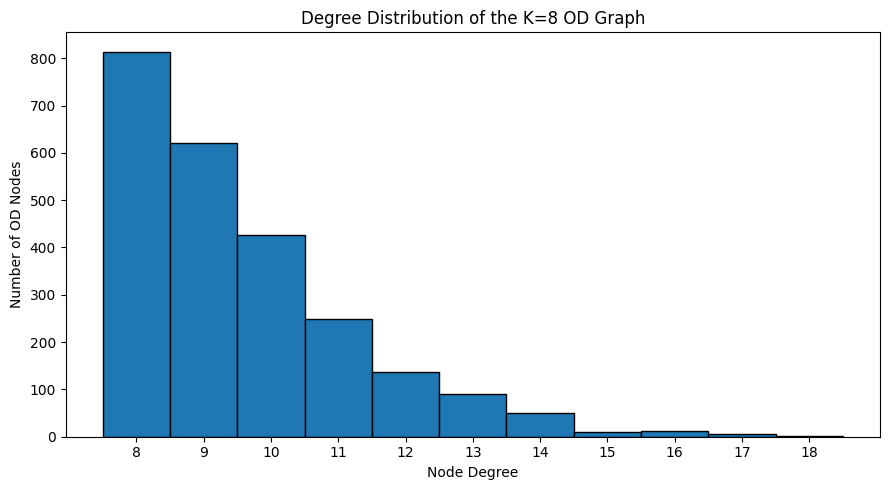

Saved figure to: ..\Output\Figures\stgnn_od_graph_degree_distribution_jan2024.png


In [77]:
# Creating a node-degree table
degree_table = pd.DataFrame(
    od_graph.degree(),
    columns=["node_index", "degree"]
)


# Adding OD-pair information
degree_table = degree_table.merge(
    node_table[
        [
            "node_index",
            "od_pair",
            "PU_Zone",
            "DO_Zone"
        ]
    ],
    on="node_index",
    how="left",
    validate="one_to_one"
)


# Checking the degree distribution
print("Node-degree summary:")
display(degree_table["degree"].describe())


# Showing the most connected OD nodes
highest_degree_nodes = (
    degree_table
    .sort_values(
        ["degree", "node_index"],
        ascending=[False, True]
    )
    .head(10)
)

print("Most connected OD-pair nodes:")
display(highest_degree_nodes)


# Plotting the degree distribution
plt.figure(figsize=(9, 5))

plt.hist(
    degree_table["degree"],
    bins=np.arange(
        degree_table["degree"].min(),
        degree_table["degree"].max() + 2
    ) - 0.5,
    edgecolor="black"
)

plt.xlabel("Node Degree")
plt.ylabel("Number of OD Nodes")
plt.title("Degree Distribution of the K=8 OD Graph")

plt.xticks(
    range(
        degree_table["degree"].min(),
        degree_table["degree"].max() + 1
    )
)

plt.tight_layout()


# Saving the figure
degree_figure_path = (
    figures_dir
    / "stgnn_od_graph_degree_distribution_jan2024.png"
)

plt.savefig(
    degree_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved figure to:", degree_figure_path)

Most OD nodes have around 8 to 10 connections, while only a small number have higher degrees. This shows that the K=8 graph remains fairly sparse without isolated nodes.

## Saving the Verified Graph Structure


In [79]:
# Importing JSON for saving graph information
import json


# Creating a separate folder for graph outputs
graphs_dir = project_dir / "Output" / "Graphs"
graphs_dir.mkdir(parents=True, exist_ok=True)


# Setting graph output paths
node_table_path = graphs_dir / "stgnn_od_graph_nodes_1h_jan2024.parquet"
edge_table_path = graphs_dir / "stgnn_od_graph_edges_1h_jan2024.parquet"
graphml_path = graphs_dir / "stgnn_od_graph_8nn_jan2024.graphml"
graph_metadata_path = graphs_dir / "stgnn_od_graph_metadata_jan2024.json"

candidate_summary_path = reports_dir / "stgnn_candidate_graph_summary_jan2024.csv"
degree_table_path = reports_dir / "stgnn_graph_degree_table_jan2024.csv"


# Saving graph tables
node_table.to_parquet(node_table_path, index=False)
edge_table.to_parquet(edge_table_path, index=False)

candidate_graph_summary.to_csv(candidate_summary_path, index=False)
degree_table.to_csv(degree_table_path, index=False)


# Creating a reusable graph with useful node and edge information
graph_to_save = nx.Graph()

for row in node_table.itertuples(index=False):
    graph_to_save.add_node(
        int(row.node_index),
        od_pair=str(row.od_pair),
        PULocationID=int(row.PULocationID),
        DOLocationID=int(row.DOLocationID),
        PU_Zone=str(row.PU_Zone),
        DO_Zone=str(row.DO_Zone)
    )

for row in edge_table.itertuples(index=False):
    graph_to_save.add_edge(
        int(row.source_node),
        int(row.target_node),
        relationship=str(row.edge_relationship),
        route_distance_miles=float(row.route_distance_miles)
    )


# Saving the NetworkX graph
nx.write_graphml(graph_to_save, graphml_path)


# Saving main graph information
graph_metadata = {
    "graph_representation": "Directed OD pairs represented as graph nodes",
    "spatial_edge_method": "Eight-nearest-neighbour route similarity",
    "number_of_nodes": int(od_graph.number_of_nodes()),
    "number_of_undirected_edges": int(od_graph.number_of_edges()),
    "number_of_directed_edges": int(od_graph.number_of_edges() * 2),
    "selected_k": int(SELECTED_K),
    "connected_components": int(nx.number_connected_components(od_graph)),
    "isolated_nodes": int(len(list(nx.isolates(od_graph)))),
    "minimum_degree": int(degree_table["degree"].min()),
    "median_degree": float(degree_table["degree"].median()),
    "maximum_degree": int(degree_table["degree"].max()),
    "coordinate_reference_system": str(taxi_zones.crs),
    "historical_window_hours": 24,
    "prediction_target": "target_1h",
    "temporal_split": "Target-hour-based chronological train-validation-test split"
}

with open(graph_metadata_path, "w", encoding="utf-8") as file:
    json.dump(graph_metadata, file, indent=4)


# Checking saved graph outputs
saved_graph_files = [
    node_table_path,
    edge_table_path,
    candidate_summary_path,
    degree_table_path,
    graphml_path,
    graph_metadata_path
]

for file in saved_graph_files:
    print(file.name, ":", "Saved" if file.exists() else "Not saved")

stgnn_od_graph_nodes_1h_jan2024.parquet : Saved
stgnn_od_graph_edges_1h_jan2024.parquet : Saved
stgnn_candidate_graph_summary_jan2024.csv : Saved
stgnn_graph_degree_table_jan2024.csv : Saved
stgnn_od_graph_8nn_jan2024.graphml : Saved
stgnn_od_graph_metadata_jan2024.json : Saved


In [102]:
# Importing PyTorch
import torch

# Selecting GPU when available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Selected computing device:", device)

Selected computing device: cpu


## Selecting the GAT-GRU Model Inputs

Using the same 24-hour historical window and 20 input features as the LSTM for the one-hour-ahead GAT-GRU model.

In [121]:
# Setting the one-hour-ahead target and historical window

target_col = "target_1h"
stgnn_sequence_length = 24


# Reusing the same 20 numerical features as the LSTM

stgnn_feature_cols = lstm_feature_cols.copy()


# Checking the selected GAT-GRU inputs

missing_stgnn_features = [
    column
    for column in stgnn_feature_cols
    if column not in od_model_data.columns
]

non_numeric_stgnn_features = [
    column
    for column in stgnn_feature_cols
    if not pd.api.types.is_numeric_dtype(
        od_model_data[column]
    )
]


print("Target column:", target_col)
print("Historical window:", stgnn_sequence_length, "hours")
print("Number of input features:", len(stgnn_feature_cols))
print("Missing input features:", missing_stgnn_features)
print("Non-numeric input features:", non_numeric_stgnn_features)
print("Graph nodes:", len(node_table))

Target column: target_1h
Historical window: 24 hours
Number of input features: 20
Missing input features: []
Non-numeric input features: []
Graph nodes: 2418


## Aligning the Modelling Data with Graph Nodes


In [82]:
# Creating the OD-pair to graph-node mapping

node_mapping = node_table[
    ["od_pair", "node_index"]
].copy()


# Adding graph node indices to the modelling data

df_graph = od_model_data.merge(
    node_mapping,
    on="od_pair",
    how="left",
    validate="many_to_one"
)


# Ordering each timestamp using the same graph-node order

df_graph = (
    df_graph
    .sort_values(["pickup_hour", "node_index"])
    .reset_index(drop=True)
)


# Checking the graph-time panel

missing_node_indices = df_graph["node_index"].isna().sum()

duplicate_time_nodes = df_graph.duplicated(
    subset=["pickup_hour", "node_index"]
).sum()

nodes_per_timestamp = (
    df_graph
    .groupby("pickup_hour")["node_index"]
    .nunique()
)

expected_rows = (
    df_graph["pickup_hour"].nunique()
    * len(node_table)
)


print("Graph-aligned rows:", len(df_graph))
print("Expected rows:", expected_rows)
print("Missing node indices:", int(missing_node_indices))
print("Duplicate timestamp-node rows:", int(duplicate_time_nodes))

print("\nMinimum nodes per timestamp:", nodes_per_timestamp.min())
print("Maximum nodes per timestamp:", nodes_per_timestamp.max())

print(
    "Complete graph-time panel:",
    len(df_graph) == expected_rows
    and missing_node_indices == 0
    and duplicate_time_nodes == 0
    and nodes_per_timestamp.min() == len(node_table)
)

Graph-aligned rows: 1738542
Expected rows: 1738542
Missing node indices: 0
Duplicate timestamp-node rows: 0

Minimum nodes per timestamp: 2418
Maximum nodes per timestamp: 2418
Complete graph-time panel: True


## Scaling the GAT-GRU Input Features

Standardising the 20 input features using only the training data to avoid data leakage.

In [88]:
# Creating the training-row mask
train_mask = df_graph["data_split"].eq("train")


# Creating and fitting the feature scaler using training data only
stgnn_feature_scaler = StandardScaler()

stgnn_feature_scaler.fit(
    df_graph.loc[train_mask, stgnn_feature_cols]
)


# Scaling all observations using the fitted training scaler
scaled_graph_features = stgnn_feature_scaler.transform(
    df_graph[stgnn_feature_cols]
).astype(np.float32)


# Checking the scaled features
scaled_training_features = scaled_graph_features[
    train_mask.to_numpy()
]

maximum_absolute_training_mean = np.abs(
    scaled_training_features.mean(axis=0)
).max()


print("Scaled feature shape:", scaled_graph_features.shape)
print("Scaled feature data type:", scaled_graph_features.dtype)
print("Contains non-finite values:",not np.isfinite(scaled_graph_features).all())

print("Maximum absolute training feature mean:",round(float(maximum_absolute_training_mean), 6))

Scaled feature shape: (1738542, 20)
Scaled feature data type: float32
Contains non-finite values: False
Maximum absolute training feature mean: 0.00123


## Reshaping the Graph-Time Panel

Reshaping the scaled data into hourly graph observations while keeping the same OD node order at every timestamp.

In [89]:
# Setting the graph-time panel dimensions
n_timesteps = df_graph["pickup_hour"].nunique()
n_graph_nodes = len(node_table)
n_graph_features = len(stgnn_feature_cols)


# Checking the expected number of rows
expected_graph_rows = n_timesteps * n_graph_nodes

assert len(df_graph) == expected_graph_rows, (
    "The graph-time panel is incomplete."
)


# Checking that every timestamp uses the same node order
node_index_matrix = (
    df_graph["node_index"]
    .to_numpy(dtype=np.int32)
    .reshape(n_timesteps, n_graph_nodes)
)

expected_node_order = np.arange(
    n_graph_nodes,
    dtype=np.int32
)

same_node_order = np.all(
    node_index_matrix
    == expected_node_order[None, :]
)


# Reshaping the scaled features
graph_feature_panel = scaled_graph_features.reshape(
    n_timesteps,
    n_graph_nodes,
    n_graph_features
)


# Reshaping the one-hour-ahead target
graph_target_panel = (
    df_graph[target_col]
    .to_numpy(dtype=np.float32)
    .reshape(n_timesteps, n_graph_nodes)
)


# Keeping the hourly timestamps
shared_timestamps = (
    df_graph["pickup_hour"]
    .drop_duplicates()
    .to_numpy()
)


# Keeping one split label for each timestamp
split_labels_per_timestamp = (
    df_graph.groupby("pickup_hour")["data_split"]
    .nunique()
)

shared_split_labels = (
    df_graph.groupby("pickup_hour")["data_split"]
    .first()
    .to_numpy()
)


# Checking the graph-time panel
print("Timesteps:", n_timesteps)
print("Graph nodes:", n_graph_nodes)
print("Features per node:", n_graph_features)

print("\nGraph feature panel shape:", graph_feature_panel.shape)
print("Graph target panel shape:", graph_target_panel.shape)
print("Timestamp array shape:", shared_timestamps.shape)

print("\nSame node order at every timestamp:", same_node_order)

print("Maximum split labels per timestamp:",int(split_labels_per_timestamp.max()))

print("Feature panel contains non-finite values:",not np.isfinite(graph_feature_panel).all())

print("Target panel contains non-finite values:",not np.isfinite(graph_target_panel).all())

Timesteps: 719
Graph nodes: 2418
Features per node: 20

Graph feature panel shape: (719, 2418, 20)
Graph target panel shape: (719, 2418)
Timestamp array shape: (719,)

Same node order at every timestamp: True
Maximum split labels per timestamp: 1
Feature panel contains non-finite values: False
Target panel contains non-finite values: False


## Creating 24-Hour Graph Sequence Endpoints

Creating valid 24-hour sequence endpoints and keeping the chronological training, validation and test split.

In [87]:
# Creating valid sequence endpoints
sequence_end_indices = np.arange(
    stgnn_sequence_length - 1,
    n_timesteps,
    dtype=np.int32
)


# Getting the split label for each sequence target
sequence_split_labels = shared_split_labels[
    sequence_end_indices
]


# Separating training, validation and test endpoints
train_sequence_endpoints = sequence_end_indices[
    sequence_split_labels == "train"
]

val_sequence_endpoints = sequence_end_indices[
    sequence_split_labels == "validation"
]

test_sequence_endpoints = sequence_end_indices[
    sequence_split_labels == "test"
]


# Checking sequence counts
print("Sequence length:", stgnn_sequence_length)

print("\nTraining sequence endpoints:", len(train_sequence_endpoints))
print("Validation sequence endpoints:", len(val_sequence_endpoints))
print("Test sequence endpoints:", len(test_sequence_endpoints))

print("Total sequence endpoints:",len(sequence_end_indices))


# Checking target timestamps
print("\nFirst training target timestamp:",shared_timestamps[train_sequence_endpoints[0]])

print("Last training target timestamp:",shared_timestamps[train_sequence_endpoints[-1]])

print("\nFirst validation target timestamp:",shared_timestamps[val_sequence_endpoints[0]])

print("Last validation target timestamp:",shared_timestamps[val_sequence_endpoints[-1]])

print("\nFirst test target timestamp:",shared_timestamps[test_sequence_endpoints[0]])

print("Last test target timestamp:",shared_timestamps[test_sequence_endpoints[-1]])

Sequence length: 24

Training sequence endpoints: 504
Validation sequence endpoints: 96
Test sequence endpoints: 96
Total sequence endpoints: 696

First training target timestamp: 2024-01-02T23:00:00.000000000
Last training target timestamp: 2024-01-23T22:00:00.000000000

First validation target timestamp: 2024-01-23T23:00:00.000000000
Last validation target timestamp: 2024-01-27T22:00:00.000000000

First test target timestamp: 2024-01-27T23:00:00.000000000
Last test target timestamp: 2024-01-31T22:00:00.000000000


## Creating the Directed Graph Edge Index

Converting the K=8 graph into directed edges and adding one self-loop for each OD node.

In [91]:
# Creating the undirected edge array
undirected_edge_array = edge_table[
    ["source_node", "target_node"]
].to_numpy(dtype=np.int64)

# Creating edges in both directions
forward_edges = undirected_edge_array
reverse_edges = undirected_edge_array[:, [1, 0]]

# Creating one self-loop for every graph node
self_loop_nodes = np.arange(n_graph_nodes, dtype=np.int64)
self_loop_edges = np.column_stack([self_loop_nodes, self_loop_nodes])

# Combining directed edges and self-loops
directed_edge_array = np.vstack([
    forward_edges,
    reverse_edges,
    self_loop_edges
])

# Converting to PyTorch Geometric edge-index format
edge_index = torch.tensor(
    directed_edge_array.T,
    dtype=torch.long
)

# Checking the edge-index structure
source_nodes = edge_index[0]
target_nodes = edge_index[1]

self_loop_count = (source_nodes == target_nodes).sum().item()
unique_directed_edges = torch.unique(edge_index, dim=1).shape[1]

print("Edge-index shape:", tuple(edge_index.shape))
print("Edge-index data type:", edge_index.dtype)

print("\nMinimum node index:", int(edge_index.min()))
print("Maximum node index:", int(edge_index.max()))

print("\nDirected non-self edges:", len(forward_edges) * 2)
print("Self-loops:", self_loop_count)
print("Total directed edges:", edge_index.shape[1])
print("Unique directed edges:", unique_directed_edges)

print("All graph nodes represented:",len(torch.unique(torch.cat([source_nodes, target_nodes]))) == n_graph_nodes)

Edge-index shape: (2, 25522)
Edge-index data type: torch.int64

Minimum node index: 0
Maximum node index: 2417

Directed non-self edges: 23104
Self-loops: 2418
Total directed edges: 25522
Unique directed edges: 25522
All graph nodes represented: True


## Creating the Graph Sequence Dataset


In [92]:
# Importing PyTorch dataset tools
from torch.utils.data import Dataset


# Creating a memory-efficient graph sequence dataset
class GraphSequenceDataset(Dataset):

    def __init__(self, feature_panel, target_panel, end_indices, sequence_length):
        self.feature_panel = feature_panel
        self.target_panel = target_panel
        self.end_indices = np.asarray(end_indices, dtype=np.int32)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.end_indices)

    def __getitem__(self, sequence_position):

        # Getting the sequence end and start positions
        end_index = int(self.end_indices[sequence_position])
        start_index = end_index - self.sequence_length + 1

        # Extracting the 24-hour graph sequence and target
        X_sequence = self.feature_panel[start_index:end_index + 1]
        y_sequence = self.target_panel[end_index]

        # Converting to PyTorch tensors
        X_tensor = torch.from_numpy(X_sequence).float()
        y_tensor = torch.from_numpy(y_sequence).float()

        return X_tensor, y_tensor, end_index


# Creating train, validation and test datasets
train_graph_dataset = GraphSequenceDataset(
    graph_feature_panel, graph_target_panel,
    train_sequence_endpoints, stgnn_sequence_length
)

validation_graph_dataset = GraphSequenceDataset(
    graph_feature_panel, graph_target_panel,
    val_sequence_endpoints, stgnn_sequence_length
)

test_graph_dataset = GraphSequenceDataset(
    graph_feature_panel, graph_target_panel,
    test_sequence_endpoints, stgnn_sequence_length
)


# Checking the first training sequence
X_sample, y_sample, sample_end_index = train_graph_dataset[0]

sample_memory_mb = (
    X_sample.numel() * X_sample.element_size() / (1024 ** 2)
)


# Checking the graph datasets
print("Training graph sequences:", len(train_graph_dataset))
print("Validation graph sequences:", len(validation_graph_dataset))
print("Test graph sequences:", len(test_graph_dataset))

print("\nInput sequence shape:", X_sample.shape)
print("Target vector shape:", y_sample.shape)

print("\nInput data type:", X_sample.dtype)
print("Target data type:", y_sample.dtype)
print("Input contains non-finite values:", not torch.isfinite(X_sample).all().item())
print("Target contains non-finite values:", not torch.isfinite(y_sample).all().item())

print("\nApproximate input memory per sequence:", round(sample_memory_mb, 2), "MB")
print("First sequence end:", pd.Timestamp(shared_timestamps[sample_end_index]))
print(
    "First prediction time:",
    pd.Timestamp(shared_timestamps[sample_end_index]) + pd.Timedelta(hours=1)
)

Training graph sequences: 504
Validation graph sequences: 96
Test graph sequences: 96

Input sequence shape: torch.Size([24, 2418, 20])
Target vector shape: torch.Size([2418])

Input data type: torch.float32
Target data type: torch.float32
Input contains non-finite values: False
Target contains non-finite values: False

Approximate input memory per sequence: 4.43 MB
First sequence end: 2024-01-02 23:00:00
First prediction time: 2024-01-03 00:00:00


In [101]:
# Importing PyTorch Geometric and GAT layer
import torch_geometric
from torch_geometric.nn import GATConv

## Setting Reproducibility and Model Configuration

Setting the random seed and main GAT-GRU model settings before building the model.

In [94]:
# Setting the random seed
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Setting the GAT-GRU architecture
GRU_HIDDEN_UNITS = 64
GAT_OUT_CHANNELS = 32
GAT_HEADS = 2
DENSE_UNITS = 32
DROPOUT_RATE = 0.20


# Checking the configuration
print("Random seed:", SEED)
print("GRU hidden units:", GRU_HIDDEN_UNITS)
print("GAT output channels per head:", GAT_OUT_CHANNELS)
print("GAT attention heads:", GAT_HEADS)
print("Combined GAT output size:", GAT_OUT_CHANNELS * GAT_HEADS)
print("Dense units:", DENSE_UNITS)
print("Dropout rate:", DROPOUT_RATE)

Random seed: 42
GRU hidden units: 64
GAT output channels per head: 32
GAT attention heads: 2
Combined GAT output size: 64
Dense units: 32
Dropout rate: 0.2


## Building the GAT-GRU Model

Building the GAT-GRU model to learn temporal demand patterns and spatial relationships between connected OD routes.

In [96]:
# Importing neural-network tools
import torch.nn as nn
import torch.nn.functional as F


# Building the GAT-GRU model
class GATGRUModel(nn.Module):

    def __init__(self, input_features, gru_hidden_units,
                 gat_out_channels, gat_heads,
                 dense_units, dropout_rate):

        super().__init__()

        # Building the temporal GRU encoder
        self.gru = nn.GRU(
            input_size=input_features,
            hidden_size=gru_hidden_units,
            batch_first=True
        )

        # Building the graph-attention layer
        self.gat = GATConv(
            in_channels=gru_hidden_units,
            out_channels=gat_out_channels,
            heads=gat_heads,
            concat=True,
            dropout=dropout_rate,
            add_self_loops=False
        )

        # Building the prediction layers
        self.dropout = nn.Dropout(dropout_rate)
        self.dense = nn.Linear(gat_out_channels * gat_heads, dense_units)
        self.output_layer = nn.Linear(dense_units, 1)

        # Keeping predictions non-negative
        self.output_activation = nn.Softplus()


    def forward(self, x, edge_index):

        # Adding a batch dimension for one graph sequence
        if x.dim() == 3:
            x = x.unsqueeze(0)

        batch_size, sequence_length, nodes, features = x.shape

        # Rearranging data for node-level GRU processing
        x = x.permute(0, 2, 1, 3)
        x = x.reshape(batch_size * nodes, sequence_length, features)

        # Encoding each node's 24-hour history
        _, hidden_state = self.gru(x)

        node_embeddings = hidden_state[-1]
        node_embeddings = node_embeddings.reshape(batch_size, nodes, -1)

        # Applying graph attention to each graph sample
        graph_outputs = []

        for batch_index in range(batch_size):

            graph_embedding = self.gat(
                node_embeddings[batch_index],
                edge_index
            )

            graph_embedding = F.elu(graph_embedding)
            graph_outputs.append(graph_embedding)

        graph_outputs = torch.stack(graph_outputs, dim=0)

        # Creating one next-hour prediction per OD node
        graph_outputs = self.dropout(graph_outputs)
        graph_outputs = F.relu(self.dense(graph_outputs))
        graph_outputs = self.output_activation(
            self.output_layer(graph_outputs)
        )

        return graph_outputs.squeeze(-1)


# Creating the model
gat_gru_model = GATGRUModel(
    input_features=len(stgnn_feature_cols),
    gru_hidden_units=GRU_HIDDEN_UNITS,
    gat_out_channels=GAT_OUT_CHANNELS,
    gat_heads=GAT_HEADS,
    dense_units=DENSE_UNITS,
    dropout_rate=DROPOUT_RATE
).to(device)


# Counting model parameters
total_parameters = sum(p.numel() for p in gat_gru_model.parameters())
trainable_parameters = sum(
    p.numel() for p in gat_gru_model.parameters() if p.requires_grad
)


# Showing the model structure
print(gat_gru_model)

print("\nTotal parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)
print("Model device:", next(gat_gru_model.parameters()).device)

GATGRUModel(
  (gru): GRU(20, 64, batch_first=True)
  (gat): GATConv(64, 32, heads=2)
  (dropout): Dropout(p=0.2, inplace=False)
  (dense): Linear(in_features=64, out_features=32, bias=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
  (output_activation): Softplus(beta=1.0, threshold=20.0)
)

Total parameters: 22913
Trainable parameters: 22913
Model device: cpu


## Defining the Training Configuration

Setting the loss function, optimiser, learning rate and early-stopping settings for GAT-GRU training.

In [98]:
# Setting the training configuration
MAX_EPOCHS = 30
BATCH_SIZE = 1
INITIAL_LEARNING_RATE = 0.001
EARLY_STOPPING_PATIENCE = 5
GRADIENT_CLIP_NORM = 1.0

# Creating the Huber loss function
criterion = nn.HuberLoss(delta=1.0)

# Creating the Adam optimiser
optimizer = torch.optim.Adam(
    gat_gru_model.parameters(),
    lr=INITIAL_LEARNING_RATE
)

# Reducing the learning rate when validation loss stops improving
learning_rate_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

# Setting the best-model checkpoint path
best_gat_gru_path = models_dir / "best_gat_gru_model_1h_jan2024.pt"

# Checking the training configuration
print("Maximum epochs:", MAX_EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Initial learning rate:", INITIAL_LEARNING_RATE)
print("Loss function:", criterion)
print("Early-stopping patience:", EARLY_STOPPING_PATIENCE)
print("Gradient clipping norm:", GRADIENT_CLIP_NORM)
print("Best-model path:", best_gat_gru_path)

Maximum epochs: 30
Batch size: 1
Initial learning rate: 0.001
Loss function: HuberLoss()
Early-stopping patience: 5
Gradient clipping norm: 1.0
Best-model path: ..\Output\Models\best_gat_gru_model_1h_jan2024.pt


## Creating the Graph Data Loaders

Creating separate data loaders for the training, validation and test graph sequences.

In [99]:
# Importing the data-loading tool
from torch.utils.data import DataLoader

# Creating the graph data loaders
train_graph_loader = DataLoader(
    train_graph_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

validation_graph_loader = DataLoader(
    validation_graph_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_graph_loader = DataLoader(
    test_graph_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# Retrieving one training batch
X_batch, y_batch, end_index_batch = next(iter(train_graph_loader))

# Checking the data loaders
print("Training batches:", len(train_graph_loader))
print("Validation batches:", len(validation_graph_loader))
print("Test batches:", len(test_graph_loader))

print("\nInput batch shape:", tuple(X_batch.shape))
print("Target batch shape:", tuple(y_batch.shape))
print("Endpoint batch shape:", tuple(end_index_batch.shape))

print("\nInput data type:", X_batch.dtype)
print("Target data type:", y_batch.dtype)

Training batches: 504
Validation batches: 96
Test batches: 96

Input batch shape: (1, 24, 2418, 20)
Target batch shape: (1, 2418)
Endpoint batch shape: (1,)

Input data type: torch.float32
Target data type: torch.float32


## Training the GAT-GRU Model

Training the model using the training sequences and monitoring validation loss to save the best-performing model.

In [103]:
# Moving graph edges to the selected device
edge_index_device = edge_index.to(device)

# Storing training history
train_loss_history = []
val_loss_history = []

best_val_loss = np.inf
best_epoch = 0
epochs_without_improvement = 0

training_start_time = time.perf_counter()


# Training the GAT-GRU model
for epoch in range(1, MAX_EPOCHS + 1):

    # Training
    gat_gru_model.train()
    train_loss_total = 0.0

    for X_batch, y_batch, _ in train_graph_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = gat_gru_model(X_batch, edge_index_device)
        loss = criterion(predictions, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            gat_gru_model.parameters(),
            GRADIENT_CLIP_NORM
        )

        optimizer.step()

        train_loss_total += loss.item()


    train_loss = train_loss_total / len(train_graph_loader)


    # Validation
    gat_gru_model.eval()
    val_loss_total = 0.0

    with torch.no_grad():

        for X_batch, y_batch, _ in validation_graph_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = gat_gru_model(X_batch, edge_index_device)
            loss = criterion(predictions, y_batch)

            val_loss_total += loss.item()


    val_loss = val_loss_total / len(validation_graph_loader)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    # Updating the learning rate
    learning_rate_scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]


    # Saving the best validation model
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            gat_gru_model.state_dict(),
            best_gat_gru_path
        )

    else:
        epochs_without_improvement += 1


    # Showing epoch results
    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"LR: {current_lr:.6f}"
    )


    # Applying early stopping
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping triggered.")
        break


# Calculating total training time
gat_gru_training_time = (time.perf_counter() - training_start_time) / 60


# Loading the best saved model
gat_gru_model.load_state_dict(
    torch.load(
        best_gat_gru_path,
        map_location=device
    )
)

gat_gru_model.eval()


# Showing the training result
print("\nTraining completed.")
print("Epochs completed:", len(train_loss_history))
print("Best epoch:", best_epoch)
print("Best validation loss:", round(best_val_loss, 6))
print("Training time:", round(gat_gru_training_time, 2), "minutes")
print("Best model saved:", best_gat_gru_path.exists())

Epoch 01/30 | Train Loss: 0.693795 | Val Loss: 0.731205 | LR: 0.001000
Epoch 02/30 | Train Loss: 0.625420 | Val Loss: 0.680580 | LR: 0.001000
Epoch 03/30 | Train Loss: 0.603489 | Val Loss: 0.668271 | LR: 0.001000
Epoch 04/30 | Train Loss: 0.591199 | Val Loss: 0.662447 | LR: 0.001000
Epoch 05/30 | Train Loss: 0.583822 | Val Loss: 0.646416 | LR: 0.001000
Epoch 06/30 | Train Loss: 0.575236 | Val Loss: 0.639969 | LR: 0.001000
Epoch 07/30 | Train Loss: 0.572648 | Val Loss: 0.660554 | LR: 0.001000
Epoch 08/30 | Train Loss: 0.569140 | Val Loss: 0.632600 | LR: 0.001000
Epoch 09/30 | Train Loss: 0.564346 | Val Loss: 0.659561 | LR: 0.001000
Epoch 10/30 | Train Loss: 0.561009 | Val Loss: 0.637200 | LR: 0.001000
Epoch 11/30 | Train Loss: 0.558095 | Val Loss: 0.620389 | LR: 0.001000
Epoch 12/30 | Train Loss: 0.556051 | Val Loss: 0.631459 | LR: 0.001000
Epoch 13/30 | Train Loss: 0.551560 | Val Loss: 0.614639 | LR: 0.001000
Epoch 14/30 | Train Loss: 0.551973 | Val Loss: 0.628109 | LR: 0.001000
Epoch 

The GAT-GRU model completed 30 training epochs, with the best validation loss of 0.585909 at epoch 29. The best model weights were saved for final evaluation.

## Visualising the GAT-GRU Training History

Reloading the best model and checking how the training and validation losses changed across epochs.

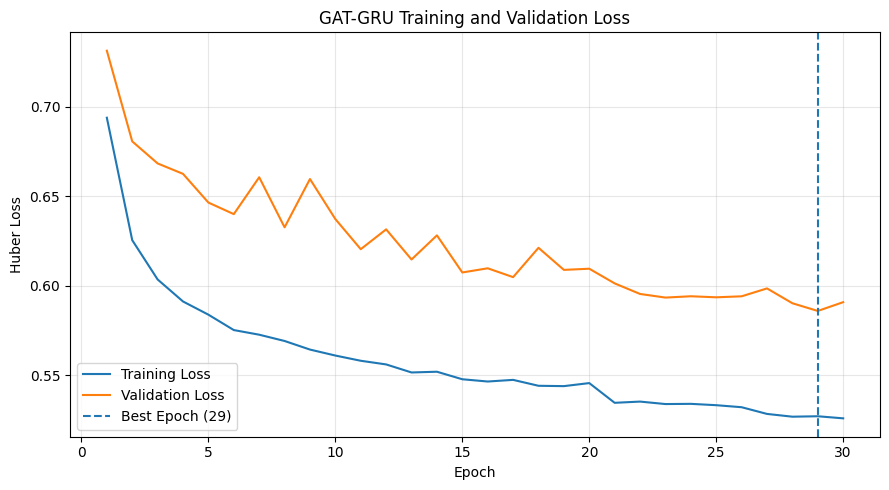

Best epoch: 29
Best validation loss: 0.585909
Training history saved: True
Training figure saved: True


In [104]:
# Reloading the best saved model
gat_gru_model.load_state_dict(
    torch.load(best_gat_gru_path, map_location=device)
)
gat_gru_model.eval()

# Creating the training-history table
training_history_df = pd.DataFrame({
    "epoch": np.arange(1, len(train_loss_history) + 1),
    "training_loss": train_loss_history,
    "validation_loss": val_loss_history
})

# Saving the training history
training_history_path = reports_dir / "gat_gru_training_history_1h_jan2024.csv"
training_history_df.to_csv(training_history_path, index=False)

# Plotting training and validation loss
plt.figure(figsize=(9, 5))

plt.plot(training_history_df["epoch"], training_history_df["training_loss"], label="Training Loss")
plt.plot(training_history_df["epoch"], training_history_df["validation_loss"], label="Validation Loss")
plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch ({best_epoch})")

plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.title("GAT-GRU Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Saving the figure
training_figure_path = figures_dir / "gat_gru_training_history_1h_jan2024.png"
plt.savefig(training_figure_path, dpi=300, bbox_inches="tight")
plt.show()

# Checking the saved results
print("Best epoch:", best_epoch)
print("Best validation loss:", round(best_val_loss, 6))
print("Training history saved:", training_history_path.exists())
print("Training figure saved:", training_figure_path.exists())

The training and validation losses decreased during training, with the best validation performance reached at epoch 29. The corresponding model weights were used for evaluation.

## Generating GAT-GRU Validation Predictions

Generating one-hour-ahead predictions for the validation period using the best GAT-GRU model.

In [106]:
# Creating a function for generating graph predictions
def generate_graph_predictions(model, data_loader, edge_index, device):

    model.eval()

    predictions_list = []
    targets_list = []
    endpoint_indices_list = []

    prediction_start_time = time.perf_counter()

    with torch.no_grad():

        for X_batch, y_batch, end_index_batch in data_loader:

            X_batch = X_batch.to(device)

            batch_predictions = model(
                X_batch,
                edge_index
            )

            predictions_list.append(batch_predictions.cpu().numpy())
            targets_list.append(y_batch.numpy())
            endpoint_indices_list.append(end_index_batch.numpy())

    prediction_time = time.perf_counter() - prediction_start_time

    predictions_array = np.concatenate(predictions_list, axis=0)
    targets_array = np.concatenate(targets_list, axis=0)
    endpoint_indices_array = np.concatenate(endpoint_indices_list, axis=0)

    return predictions_array, targets_array, endpoint_indices_array, prediction_time


# Generating validation predictions
(
    validation_predictions,
    validation_targets,
    validation_prediction_endpoints,
    validation_prediction_time
) = generate_graph_predictions(
    gat_gru_model,
    validation_graph_loader,
    edge_index_device,
    device
)


# Creating validation prediction timestamps
validation_prediction_times = (
    pd.to_datetime(
        shared_timestamps[validation_prediction_endpoints]
    )
    + pd.Timedelta(hours=1)
)


# Checking the validation predictions
print("Validation prediction shape:", validation_predictions.shape)
print("Validation target shape:", validation_targets.shape)

print("\nPredictions contain non-finite values:",not np.isfinite(validation_predictions).all())

print("Negative predictions:",int((validation_predictions < 0).sum()))

print("\nValidation prediction time:",round(validation_prediction_time, 2), "seconds")

print("Validation prediction period:",validation_prediction_times.min(),"to",validation_prediction_times.max())

Validation prediction shape: (96, 2418)
Validation target shape: (96, 2418)

Predictions contain non-finite values: False
Negative predictions: 0

Validation prediction time: 5.7 seconds
Validation prediction period: 2024-01-24 00:00:00 to 2024-01-27 23:00:00


## Evaluating GAT-GRU Validation Performance

Evaluating the GAT-GRU predictions on the validation period using the same metrics as the previous OD models.

In [107]:
# Flattening validation targets and predictions
y_val_gat_gru = validation_targets.reshape(-1)
val_pred_gat_gru = validation_predictions.reshape(-1)

# Checking the evaluation arrays
print("Validation targets:", y_val_gat_gru.shape)
print("Validation predictions:", val_pred_gat_gru.shape)

# Evaluating validation performance
gat_gru_val_metrics = evaluate_model(
    y_true=y_val_gat_gru,
    y_pred=val_pred_gat_gru,
    model_name="GAT-GRU",
    split_name="Validation"
)

# Creating the validation-results table
gat_gru_validation_results = pd.DataFrame([gat_gru_val_metrics])

display(gat_gru_validation_results)

Validation targets: (232128,)
Validation predictions: (232128,)


,Model,Split,MAE,RMSE,R2,WMAPE_%,MAPE_nonzero_%
0,GAT-GRU,Validation,0.906507,1.883218,0.672294,58.533054,54.069443


## Generating GAT-GRU Test Predictions

Generating one-hour-ahead predictions for the unseen test period using the best GAT-GRU model.

In [108]:
# Generating test predictions
(
    test_predictions,
    test_targets,
    test_prediction_endpoints,
    test_prediction_time
) = generate_graph_predictions(
    gat_gru_model,
    test_graph_loader,
    edge_index_device,
    device
)

# Creating test prediction timestamps
test_prediction_times = (
    pd.to_datetime(shared_timestamps[test_prediction_endpoints])
    + pd.Timedelta(hours=1)
)

# Checking the test predictions
print("Test prediction shape:", test_predictions.shape)
print("Test target shape:", test_targets.shape)
print("Predictions contain non-finite values:", not np.isfinite(test_predictions).all())
print("Negative predictions:", int((test_predictions < 0).sum()))
print("Test prediction time:", round(test_prediction_time, 2), "seconds")
print("Test prediction period:", test_prediction_times.min(), "to", test_prediction_times.max())

Test prediction shape: (96, 2418)
Test target shape: (96, 2418)
Predictions contain non-finite values: False
Negative predictions: 0
Test prediction time: 5.56 seconds
Test prediction period: 2024-01-28 00:00:00 to 2024-01-31 23:00:00


## Evaluating GAT-GRU Test Performance

Evaluating the final GAT-GRU predictions on the unseen test period using the same metrics as the previous OD models.

In [109]:
# Flattening test targets and predictions
y_test_gat_gru = test_targets.reshape(-1)
test_pred_gat_gru = test_predictions.reshape(-1)

# Checking the evaluation arrays
print("Test targets:", y_test_gat_gru.shape)
print("Test predictions:", test_pred_gat_gru.shape)

# Evaluating test performance
gat_gru_test_metrics = evaluate_model(
    y_true=y_test_gat_gru,
    y_pred=test_pred_gat_gru,
    model_name="GAT-GRU",
    split_name="Test"
)

# Creating the test-results table
gat_gru_test_results = pd.DataFrame([gat_gru_test_metrics])

display(gat_gru_test_results)

Test targets: (232128,)
Test predictions: (232128,)


,Model,Split,MAE,RMSE,R2,WMAPE_%,MAPE_nonzero_%
0,GAT-GRU,Test,0.822666,1.750573,0.677661,61.450958,54.748833


## Comparing All OD Forecasting Models

Comparing Persistence, Random Forest, LSTM and GAT-GRU using the same validation and test metrics.

In [112]:
# Combining the GAT-GRU validation and test results
gat_gru_metrics = pd.concat(
    [gat_gru_validation_results, gat_gru_test_results],
    ignore_index=True
)

# Adding GAT-GRU to the existing OD model comparison
final_model_comparison = pd.concat(
    [final_model_comparison, gat_gru_metrics],
    ignore_index=True
)

# Removing duplicates if the cell is rerun
final_model_comparison = final_model_comparison.drop_duplicates(
    subset=["Model", "Split"],
    keep="last"
)

# Setting model and split order
model_order = ["Persistence Baseline", "Random Forest", "LSTM", "GAT-GRU"]
split_order = ["Validation", "Test"]

final_model_comparison["Model"] = pd.Categorical(
    final_model_comparison["Model"],
    categories=model_order,
    ordered=True
)

final_model_comparison["Split"] = pd.Categorical(
    final_model_comparison["Split"],
    categories=split_order,
    ordered=True
)

# Sorting the comparison table
final_model_comparison = (
    final_model_comparison
    .sort_values(["Split", "Model"])
    .reset_index(drop=True)
)

# Creating the final test comparison
test_model_comparison = (
    final_model_comparison[
        final_model_comparison["Split"] == "Test"
    ]
    .copy()
    .reset_index(drop=True)
)

# Saving the comparison
comparison_metrics_path = reports_dir / "od_model_comparison_1h_jan2024.csv"
final_model_comparison.to_csv(comparison_metrics_path, index=False)

display(test_model_comparison)
print("Model comparison saved:", comparison_metrics_path.exists())

,Model,Split,MAE,RMSE,R2,WMAPE_%,MAPE_nonzero_%
0,Persistence Baseline,Test,0.962783,1.899151,0.620622,71.917376,76.890533
1,Random Forest,Test,0.829607,1.476327,0.770746,61.969452,55.214325
2,LSTM,Test,0.761381,1.411329,0.790488,56.873165,54.129696
3,GAT-GRU,Test,0.822666,1.750573,0.677661,61.450958,54.748833


Model comparison saved: True


The LSTM achieved the strongest overall OD-level test performance, with the lowest MAE, RMSE and WMAPE and the highest R². GAT-GRU improved on persistence but did not outperform the LSTM, showing that the more complex graph-based model did not provide the best forecasting accuracy in this experiment.

## Saving GAT-GRU Evaluation Outputs


In [113]:
# Creating a reusable prediction table
def create_graph_prediction_table(predictions, targets, prediction_times, node_table, split_name):

    n_times = len(prediction_times)

    prediction_table = pd.DataFrame({
        "prediction_time": np.repeat(prediction_times, len(node_table)),
        "node_index": np.tile(node_table["node_index"].to_numpy(), n_times),
        "od_pair": np.tile(node_table["od_pair"].to_numpy(), n_times),
        "PULocationID": np.tile(node_table["PULocationID"].to_numpy(), n_times),
        "DOLocationID": np.tile(node_table["DOLocationID"].to_numpy(), n_times),
        "PU_Zone": np.tile(node_table["PU_Zone"].to_numpy(), n_times),
        "DO_Zone": np.tile(node_table["DO_Zone"].to_numpy(), n_times),
        "data_split": split_name,
        "target_1h": targets.reshape(-1),
        "gat_gru_pred_1h": predictions.reshape(-1)
    })

    # Creating rounded predictions and absolute errors
    prediction_table["gat_gru_pred_1h_rounded"] = np.rint(
        prediction_table["gat_gru_pred_1h"]
    ).astype(int)

    prediction_table["absolute_error"] = np.abs(
        prediction_table["target_1h"] - prediction_table["gat_gru_pred_1h"]
    )

    return prediction_table


# Creating validation and test prediction tables
gat_gru_validation_predictions_df = create_graph_prediction_table(
    validation_predictions, validation_targets,
    validation_prediction_times, node_table, "Validation"
)

gat_gru_test_predictions_df = create_graph_prediction_table(
    test_predictions, test_targets,
    test_prediction_times, node_table, "Test"
)

# Setting output paths
gat_gru_metrics_path = reports_dir / "gat_gru_metrics_1h_jan2024.csv"
gat_gru_validation_path = reports_dir / "gat_gru_validation_predictions_1h_jan2024.parquet"
gat_gru_test_path = reports_dir / "gat_gru_test_predictions_1h_jan2024.parquet"

# Saving results
gat_gru_metrics.to_csv(gat_gru_metrics_path, index=False)
gat_gru_validation_predictions_df.to_parquet(gat_gru_validation_path, index=False)
gat_gru_test_predictions_df.to_parquet(gat_gru_test_path, index=False)

# Checking saved outputs
print("GAT-GRU metrics shape:", gat_gru_metrics.shape)
print("Validation prediction rows:", len(gat_gru_validation_predictions_df))
print("Test prediction rows:", len(gat_gru_test_predictions_df))
print("Metrics saved:", gat_gru_metrics_path.exists())
print("Validation predictions saved:", gat_gru_validation_path.exists())
print("Test predictions saved:", gat_gru_test_path.exists())

display(gat_gru_test_predictions_df.head())

GAT-GRU metrics shape: (2, 7)
Validation prediction rows: 232128
Test prediction rows: 232128
Metrics saved: True
Validation predictions saved: True
Test predictions saved: True


,prediction_time,node_index,od_pair,PULocationID,DOLocationID,PU_Zone,DO_Zone,data_split,target_1h,gat_gru_pred_1h,gat_gru_pred_1h_rounded,absolute_error
0,2024-01-28,0,4_79,4,79,Alphabet City,East Village,Test,3.0,2.577291,3,0.422709
1,2024-01-28,1,4_107,4,107,Alphabet City,Gramercy,Test,3.0,1.158646,1,1.841354
2,2024-01-28,2,4_114,4,114,Alphabet City,Greenwich Village South,Test,4.0,1.457645,1,2.542355
3,2024-01-28,3,4_148,4,148,Alphabet City,Lower East Side,Test,3.0,1.643283,2,1.356717
4,2024-01-28,4,4_249,4,249,Alphabet City,West Village,Test,1.0,5.475776,5,4.475776


## Visualising the Final Test Model Comparison

Comparing the test-set MAE and RMSE of Persistence, Random Forest, LSTM and GAT-GRU.

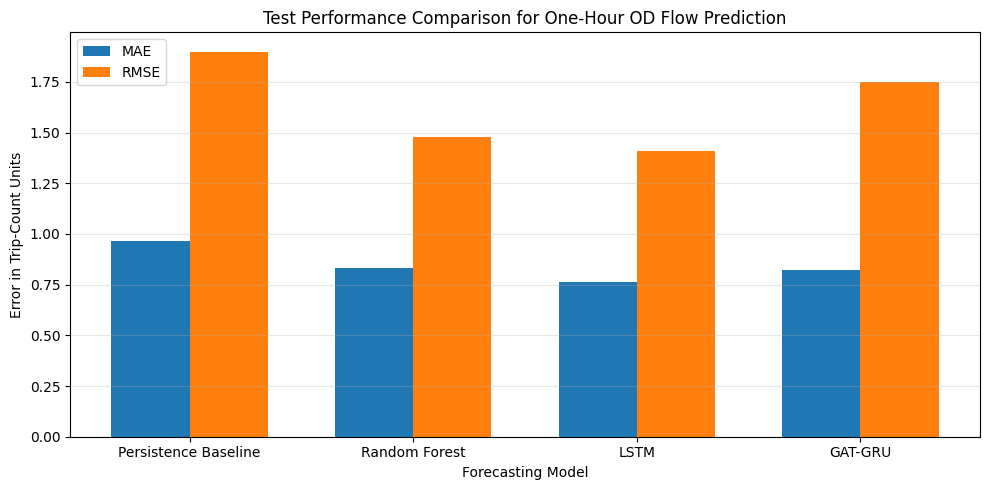

Comparison figure saved: True


In [115]:
# Preparing the test comparison data
comparison_plot_data = test_model_comparison.copy()

model_names = comparison_plot_data["Model"].astype(str)
mae_values = comparison_plot_data["MAE"].to_numpy()
rmse_values = comparison_plot_data["RMSE"].to_numpy()

# Setting bar positions
x_positions = np.arange(len(model_names))
bar_width = 0.35

# Plotting MAE and RMSE
plt.figure(figsize=(10, 5))

plt.bar(x_positions - bar_width / 2, mae_values, width=bar_width, label="MAE")
plt.bar(x_positions + bar_width / 2, rmse_values, width=bar_width, label="RMSE")

plt.xlabel("Forecasting Model")
plt.ylabel("Error in Trip-Count Units")
plt.title("Test Performance Comparison for One-Hour OD Flow Prediction")
plt.xticks(x_positions, model_names)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# Saving the figure
comparison_figure_path = figures_dir / "final_model_test_comparison_1h_jan2024.png"
plt.savefig(comparison_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Comparison figure saved:", comparison_figure_path.exists())

The LSTM produced the lowest MAE and RMSE on the OD-level test set, confirming its strongest overall forecasting performance. GAT-GRU improved on persistence but showed higher RMSE than Random Forest and LSTM.

## Analysing Errors by Demand Level

Examining GAT-GRU test errors across different OD-demand levels to identify where the largest forecasting errors occur.

In [123]:
# Creating demand-level categories
demand_band_labels = [
    "Zero demand",
    "Low demand (1–2)",
    "Moderate demand (3–5)",
    "High demand (6–10)",
    "Very high demand (>10)"
]

gat_gru_test_predictions_df["demand_band"] = pd.cut(
    gat_gru_test_predictions_df["target_1h"],
    bins=[-0.1, 0, 2, 5, 10, np.inf],
    labels=demand_band_labels
)

# Calculating errors for each demand level
demand_band_rows = []

for demand_band in demand_band_labels:

    band_data = gat_gru_test_predictions_df[
        gat_gru_test_predictions_df["demand_band"] == demand_band
    ]

    if len(band_data) == 0:
        continue

    y_true_band = band_data["target_1h"].to_numpy()
    y_pred_band = band_data["gat_gru_pred_1h"].to_numpy()

    demand_band_rows.append({
        "Demand_Band": demand_band,
        "Observations": len(band_data),
        "Observation_Percentage": len(band_data) / len(gat_gru_test_predictions_df) * 100,
        "Mean_Actual": y_true_band.mean(),
        "Mean_Prediction": y_pred_band.mean(),
        "MAE": np.mean(np.abs(y_true_band - y_pred_band)),
        "RMSE": np.sqrt(np.mean((y_true_band - y_pred_band) ** 2))
    })

# Creating and saving the summary
demand_band_summary = pd.DataFrame(demand_band_rows)

demand_band_summary_path = reports_dir / "gat_gru_error_by_demand_level_jan2024.csv"
demand_band_summary.to_csv(demand_band_summary_path, index=False)

display(demand_band_summary)

print("Total analysed observations:", demand_band_summary["Observations"].sum())
print("Demand-level analysis saved:", demand_band_summary_path.exists())

,Demand_Band,Observations,Observation_Percentage,Mean_Actual,Mean_Prediction,MAE,RMSE
0,Zero demand,134750,58.049869,0.000000,0.355687,0.355687,0.556630
1,Low demand (1–2),61054,26.301868,1.316163,1.039713,0.799094,1.041156
2,Moderate demand (3–5),22329,9.619262,3.709257,2.712242,1.699361,2.048144
3,High demand (6–10),9472,4.080507,7.456503,5.612603,2.955009,3.465283
4,Very high demand (>10),4523,1.948494,17.012823,11.579712,6.259618,9.357124


Total analysed observations: 232128
Demand-level analysis saved: True


The GAT-GRU performed well for zero and low-demand OD flows, which make up most of the test observations. Errors increased substantially as demand increased, with the model tending to underpredict high and very high OD flows. This helps explain the relatively high overall RMSE.

## Visualising Hourly Actual and Predicted Demand

Comparing aggregated actual and predicted OD flows across the test period to examine how well the GAT-GRU captures overall hourly demand variation.

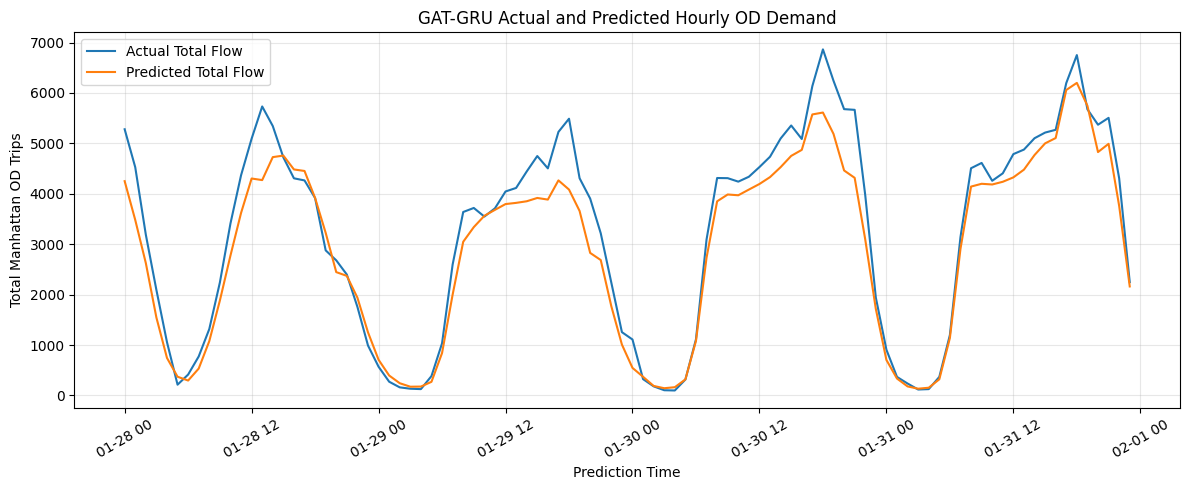

Hourly prediction records: 96
Mean hourly absolute error: 389.55
Maximum hourly absolute error: 1460.3
Hourly comparison figure saved: True


In [117]:
# Aggregating actual and predicted OD flows by prediction hour
hourly_prediction_summary = (
    gat_gru_test_predictions_df
    .groupby("prediction_time")
    .agg(
        actual_total_flow=("target_1h", "sum"),
        predicted_total_flow=("gat_gru_pred_1h", "sum")
    )
    .reset_index()
)

# Calculating hourly absolute error
hourly_prediction_summary["absolute_error"] = np.abs(
    hourly_prediction_summary["actual_total_flow"]
    - hourly_prediction_summary["predicted_total_flow"]
)

# Plotting actual and predicted hourly demand
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_prediction_summary["prediction_time"],
    hourly_prediction_summary["actual_total_flow"],
    label="Actual Total Flow"
)

plt.plot(
    hourly_prediction_summary["prediction_time"],
    hourly_prediction_summary["predicted_total_flow"],
    label="Predicted Total Flow"
)

plt.xlabel("Prediction Time")
plt.ylabel("Total Manhattan OD Trips")
plt.title("GAT-GRU Actual and Predicted Hourly OD Demand")
plt.xticks(rotation=30)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Saving the figure
hourly_prediction_figure_path = (
    figures_dir / "gat_gru_hourly_actual_vs_predicted_jan2024.png"
)

plt.savefig(hourly_prediction_figure_path, dpi=300, bbox_inches="tight")
plt.show()

# Checking the hourly summary
print("Hourly prediction records:", len(hourly_prediction_summary))
print("Mean hourly absolute error:", round(hourly_prediction_summary["absolute_error"].mean(), 2))
print("Maximum hourly absolute error:", round(hourly_prediction_summary["absolute_error"].max(), 2))
print("Hourly comparison figure saved:", hourly_prediction_figure_path.exists())

The GAT-GRU captured the overall hourly demand pattern across the test period, including the main daily peaks and low-demand periods. However, it tended to underpredict some of the highest demand peaks, consistent with the larger errors observed for high-demand OD flows.

## Saving the Final GAT-GRU Model

Saving the trained GAT-GRU model, feature scaler, graph edge index and model configuration for future use.

In [118]:
# Setting final artifact paths
gat_gru_final_model_path = models_dir / "gat_gru_od_model_1h_jan2024.pt"
gat_gru_scaler_path = models_dir / "gat_gru_feature_scaler_1h_jan2024.joblib"
gat_gru_edge_index_path = graphs_dir / "gat_gru_edge_index_1h_jan2024.pt"
gat_gru_config_path = models_dir / "gat_gru_model_config_1h_jan2024.json"

# Saving the fitted feature scaler
joblib.dump(stgnn_feature_scaler, gat_gru_scaler_path)

# Saving the graph edge index
torch.save(edge_index.cpu(), gat_gru_edge_index_path)

# Saving the final model with important metadata
torch.save({
    "model_state_dict": gat_gru_model.state_dict(),
    "best_epoch": int(best_epoch),
    "best_validation_loss": float(best_val_loss),
    "input_features": stgnn_feature_cols,
    "sequence_length": int(stgnn_sequence_length),
    "number_of_nodes": int(n_graph_nodes),
    "selected_k": int(SELECTED_K)
}, gat_gru_final_model_path)

# Creating the model configuration
gat_gru_config = {
    "model": "GAT-GRU",
    "forecast_horizon_hours": 1,
    "sequence_length": int(stgnn_sequence_length),
    "number_of_nodes": int(n_graph_nodes),
    "number_of_features": len(stgnn_feature_cols),
    "selected_k": int(SELECTED_K),
    "gru_hidden_units": int(GRU_HIDDEN_UNITS),
    "gat_out_channels": int(GAT_OUT_CHANNELS),
    "gat_heads": int(GAT_HEADS),
    "dense_units": int(DENSE_UNITS),
    "dropout_rate": float(DROPOUT_RATE),
    "best_epoch": int(best_epoch),
    "best_validation_loss": float(best_val_loss),
    "test_MAE": float(gat_gru_test_metrics["MAE"]),
    "test_RMSE": float(gat_gru_test_metrics["RMSE"]),
    "test_R2": float(gat_gru_test_metrics["R2"]),
    "test_WMAPE_percent": float(gat_gru_test_metrics["WMAPE_%"]),
    "test_MAPE_nonzero_percent": float(gat_gru_test_metrics["MAPE_nonzero_%"])
}

with open(gat_gru_config_path, "w") as file:
    json.dump(gat_gru_config, file, indent=4)

# Checking saved artifacts
print("Final model saved:", gat_gru_final_model_path.exists())
print("Feature scaler saved:", gat_gru_scaler_path.exists())
print("Edge index saved:", gat_gru_edge_index_path.exists())
print("Model configuration saved:", gat_gru_config_path.exists())

Final model saved: True
Feature scaler saved: True
Edge index saved: True
Model configuration saved: True


## Summarising OD-Level Forecasting Results

The LSTM achieved the best overall OD-level forecasting performance. Random Forest also performed well, while GAT-GRU improved on persistence but produced larger errors for high-demand OD flows.